In [ ]:
# Importing the modules
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from prophet import Prophet


In [ ]:
import statsmodels.api as sm

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
from prophet import Prophet

from prophet.diagnostics import cross_validation
from prophet.diagnostics import performance_metrics

In [ ]:
#para tunear hiperparámetros
# Python

import itertools
import numpy as np
import pandas as pd

# Analisis exploratorio

In [ ]:
casosdengue2018 = pd.read_excel("/content/dengue2018.xlsx",index_col= None, parse_dates=True,  )
# casosdengue2018
# casosdengue2018.describe()

In [ ]:
casosdengue2019 = pd.read_excel("/content/dengue2019.xlsx",index_col= None, parse_dates=True,  )
# casosdengue2019

In [ ]:
casosdengue2020 = pd.read_excel("/content/dengue2020.xlsx",index_col= None, parse_dates=True,  )
# casosdengue2020

In [ ]:
casosdengue2021 = pd.read_excel("/content/dengue2021.xlsx",index_col= None, parse_dates=True,  )
# casosdengue2021

In [ ]:
casosdengue2022 = pd.read_excel("/content/dengue2022.xlsx",index_col= None, parse_dates=True,  )
# casosdengue2022

In [ ]:
casosdengue2023 = pd.read_excel("/content/dengue2023.xlsx",index_col= None, parse_dates=True,  )
# casosdengue2023

In [ ]:
casosdengue2024 = pd.read_excel("/content/dengue2024.xlsx",index_col= None, parse_dates=True,  )
# casosdengue2024

In [ ]:
casosdengue2025 = pd.read_excel("/content/casos_dengue2025.xlsx",index_col= None, parse_dates=True,  )
casosdengue2025

#HASTA LA SEMANA 20

,ano,semana_epidemiologica,fecha_inicio_semana_epidemiologica,grupo_etario,departamento_residencia,n_confirmados,fecha_semana_epidemiologica
0,2025,1,2024-12-29,SIN DATO,SIN DATO,0,2025-W1
1,2025,2,2025-01-05,50 a 59,SIN DATO,1,2025-W2
2,2025,3,2025-01-12,20 a 29,COMUNA 13,1,2025-W3
3,2025,4,2025-01-19,SIN DATO,SIN DATO,0,2025-W4
4,2025,5,2025-01-26,30 a 39,COMUNA 2,1,2025-W5
...,...,...,...,...,...,...,...
134,2025,19,2025-05-04,20 a 29,COMUNA 13,1,2025-W19
135,2025,19,2025-05-04,40 a 49,COMUNA 11,1,2025-W19
136,2025,19,2025-05-04,40 a 49,COMUNA 12,2,2025-W19
137,2025,19,2025-05-04,50 a 59,COMUNA 12,1,2025-W19


In [ ]:
# casosdenguetodo = pd.read_excel("/content/casosdenguetodo.xlsx",index_col= None, parse_dates=True,  )
# casosdenguetodo

In [ ]:
# casosdengue2025["ano"]
casosdengue2025.info()
# casosdengue2025.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 7 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   ano                                 139 non-null    int64         
 1   semana_epidemiologica               139 non-null    int64         
 2   fecha_inicio_semana_epidemiologica  139 non-null    datetime64[ns]
 3   grupo_etario                        139 non-null    object        
 4   departamento_residencia             139 non-null    object        
 5   n_confirmados                       139 non-null    int64         
 6   fecha_semana_epidemiologica         139 non-null    object        
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 7.7+ KB


In [ ]:
# elimino las columas que no necesito
# 'fecha_inicio_semana_epidemiologica'   la tengo que eliminar despues

casosdengue2025 = casosdengue2025.drop(columns=['grupo_etario', 'departamento_residencia', "fecha_semana_epidemiologica"  ])
casosdengue2025.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 4 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   ano                                 139 non-null    int64         
 1   semana_epidemiologica               139 non-null    int64         
 2   fecha_inicio_semana_epidemiologica  139 non-null    datetime64[ns]
 3   n_confirmados                       139 non-null    int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 4.5 KB


In [ ]:
# Elimino las columnas 'departamento_nombre', "grupo_edad_id", "grupo_etario" == Por ahora==

casosdengue2018 = casosdengue2018.drop(columns=['departamento_nombre', 'grupo_etario', 'grupo_edad_id' ])
casosdengue2018

# departamento_nombre	ano	semanas_epidemiologicas	grupo_edad_id	grupo_etario

In [ ]:
casosdengue2019 = casosdengue2019.drop(columns=['departamento_nombre', 'grupo_etario', 'grupo_edad_id' ])

casosdengue2020 = casosdengue2020.drop(columns=['departamento_nombre', 'grupo_etario', 'grupo_edad_id' ])

casosdengue2021 = casosdengue2021.drop(columns=['departamento_nombre', 'grupo_etario', 'grupo_edad_id' ])

casosdengue2022 = casosdengue2022.drop(columns=['departamento_nombre', 'grupo_etario', 'grupo_edad_id' ])

casosdengue2023 = casosdengue2023.drop(columns=['departamento_nombre', 'grupo_etario', 'grupo_edad_id' ])

casosdengue2024 = casosdengue2024.drop(columns=['departamento_nombre', 'grupo_etario', 'grupo_edad_id' ])



In [ ]:
# GRAFICO DE CORRELACIÓN

corr = casosdengue2025.set_index('semana_epidemiologica').corr()
sm.graphics.plot_corr(corr, xnames=list(corr.columns))
plt.show()

In [ ]:
casosdengue2019.plot(x='grupo_edad_id',y='cantidad_casos')

In [ ]:
casosdengue2019.plot(x='semanas_epidemiologicas',y='cantidad_casos')

In [ ]:
casosdengue2024

,ano,semanas_epidemiologicas,cantidad_casos
0,2024,1,1
1,2024,1,1
2,2024,1,2
3,2024,1,1
4,2024,1,1
...,...,...,...
2109,2024,41,1
2110,2024,42,1
2111,2024,43,1
2112,2024,50,1


In [ ]:
from matplotlib import pyplot as plt
casosdengue2019['grupo_edad_id'].plot(kind='hist', bins=20, title='grupo_edad_id')
plt.gca().spines[['top', 'right',]].set_visible(False)

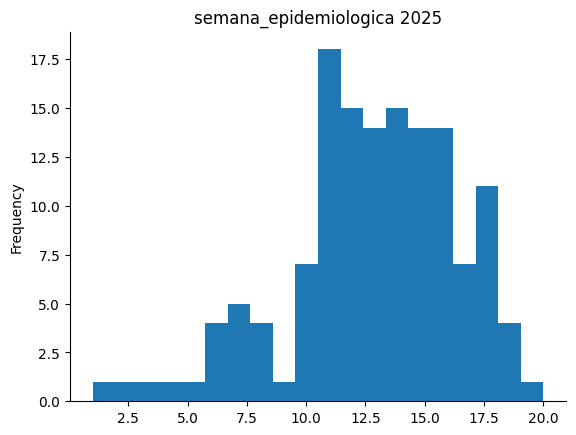

In [ ]:
from matplotlib import pyplot as plt
casosdengue2025['semana_epidemiologica'].plot(kind='hist', bins= 20, title='semana_epidemiologica 2025')
plt.gca().spines[['top', 'right',]].set_visible(False)

## arreglos para la predicción: para las bases 2018 a 2024 y para 2025

In [ ]:
# Agrupar por semanas epidemiológicas y sumar la cantidad de casos
casos_por_semana = casosdengue2025.groupby('semana_epidemiologica')['n_confirmados'].sum()

# Mapear esa suma de vuelta al DataFrame original como una nueva columna
casosdengue2025['counts'] = casosdengue2025['semana_epidemiologica'].map(casos_por_semana)

# Verificar el resultado
print(casosdengue2025)



      ano  semana_epidemiologica fecha_inicio_semana_epidemiologica  \
0    2025                      1                         2024-12-29   
1    2025                      2                         2025-01-05   
2    2025                      3                         2025-01-12   
3    2025                      4                         2025-01-19   
4    2025                      5                         2025-01-26   
..    ...                    ...                                ...   
134  2025                     19                         2025-05-04   
135  2025                     19                         2025-05-04   
136  2025                     19                         2025-05-04   
137  2025                     19                         2025-05-04   
138  2025                     20                         2025-05-11   

     n_confirmados  counts  
0                0       0  
1                1       1  
2                1       1  
3                0       0  
4 

In [ ]:
casosdengue2025['counts'].sum()

np.int64(161)

In [ ]:
#elimino duplicados

casosdengue2025= casosdengue2025.drop_duplicates(subset=['semana_epidemiologica'])
casosdengue2025 = casosdengue2025.drop(columns=['n_confirmados'])
casosdengue2025.describe()

In [ ]:
# Eliminar duplicados de 2018-2014
casosdengue2024= casosdengue2024.drop_duplicates(subset=['semanas_epidemiologicas'])
casosdengue2024 = casosdengue2024.drop(columns=['cantidad_casos'])
casosdengue2024.describe()

,ano,semanas_epidemiologicas,counts
count,30.0,30.000000,30.000000
mean,2024.0,18.466667,812.200000
std,0.0,14.195029,1042.095912
min,2024.0,1.000000,1.000000
25%,2024.0,8.250000,6.500000
50%,2024.0,15.500000,190.000000
75%,2024.0,22.750000,1493.000000
max,2024.0,52.000000,3107.000000


In [ ]:
# El 2025 : hasta la SE 20

df2025 = pd.DataFrame({
    'ano': [2025] * 20,
    'semanas_epidemiologicas': list(range(1, 21)),
    'counts': [0] * 20
})

# print(df2025)

In [ ]:
# CREO UN DF DE AÑO Y SEMANAS epidemiologicas con  los mismos nombres que la base anterior
# el 2020 tiene 53 semanas

df2024 = pd.DataFrame({
    'ano': [2024] * 52,
    'semanas_epidemiologicas': list(range(1, 53)),
    'counts': [0] * 52
})

# print(df2022)

In [ ]:
#uno los dos DF sumando filas

casosdengue2024= pd.concat([casosdengue2024,df2024])
# casosdengue2021

In [ ]:
casosdengue2025= pd.concat([casosdengue2025,df2025])

In [ ]:
#elimino diplicados por fila s/SE

casosdengue2024.drop_duplicates(subset=['semanas_epidemiologicas'],inplace=True)
# casosdengue2022

In [ ]:
casosdengue2025.drop_duplicates(subset=['semanas_epidemiologicas'],inplace=True)
casosdengue2025

In [ ]:
#verifico longitud
len(casosdengue2025 ['ano'])

In [ ]:
# ordeno segun SE de menor a mayor
casosdengue2024.sort_values(by=['semanas_epidemiologicas'], inplace=True)

# casosdengue2018["counts"].sum()

casosdengue2024.sum()


,0
ano,105248
semanas_epidemiologicas,1378
counts,24366


In [ ]:
# Convert 'ano' and 'semanas_epidemiologicas' to datetime
casosdenguese['date'] = pd.to_datetime(casosdenguese['ano'].astype(str) + '-' + casosdenguese['semanas_epidemiologicas'].astype(str) + '-1', format='%Y-%W-%w')

casosdenguese = casosdenguese.drop(columns=['ano'])
# casosdenguese


In [ ]:
# Convert 'ano' and 'semanas_epidemiologicas' to datetime
casosdengue2025['date'] = pd.to_datetime(casosdengue2025['ano'].astype(str) + '-' + casosdengue2025['semanas_epidemiologicas'].astype(str) + '-1', format='%Y-%W-%w')
casosdengue2025

,ano,semanas_epidemiologicas,counts,date
0,2025,1,0,2025-01-06
1,2025,2,1,2025-01-13
2,2025,3,1,2025-01-20
3,2025,4,0,2025-01-27
4,2025,5,1,2025-02-03
5,2025,6,4,2025-02-10
6,2025,7,7,2025-02-17
7,2025,8,4,2025-02-24
8,2025,9,1,2025-03-03
9,2025,10,9,2025-03-10


In [ ]:
casosdengue2025 = casosdengue2025.drop(columns=['ano'])

In [ ]:
casosdengue2025=casosdengue2025.set_index('date')

In [ ]:
# cambio el índice
casosdenguese = casosdenguese.set_index('date')

In [ ]:
casosdengue2018conse = pd.read_excel("/content/casosdengue2018conse.xlsx",index_col= None, parse_dates=True,  )
casosdengue2019conse = pd.read_excel("/content/casosdengue2019conse.xlsx",index_col= None, parse_dates=True,  )
casosdengue2020conse = pd.read_excel("/content/casosdengue2020conse.xlsx",index_col= None, parse_dates=True,  )
casosdengue2021conse = pd.read_excel("/content/casosdengue2021conse.xlsx",index_col= None, parse_dates=True,  )
casosdengue2022conse = pd.read_excel("/content/casosdengue2022conse.xlsx",index_col= None, parse_dates=True,  )
casosdengue2023conse = pd.read_excel("/content/casosdengue2023conse.xlsx",index_col= None, parse_dates=True,  )
casosdengue2024conse = pd.read_excel("/content/casosdengue2024conse.xlsx",index_col= None, parse_dates=True,  )


In [ ]:
# casostotal = pd.concat([casosdengue2018conse,casosdengue2019conse,casosdengue2020conse,casosdengue2021conse,casosdengue2022conse,casosdengue2023conse,casosdengue2024conse])
casostotal.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'], inplace= True)



# Base clima

In [ ]:
pip install epiweeks

In [ ]:
from datetime import date
from epiweeks import Week

In [ ]:
### BASE DE CLIMA ###

clima= pd.read_excel("/content/clima2024.xlsx")
clima

,date,tavg,tmin,tmax,prcp,wdir,wspd,pres
0,2018-01-01,22.1,18.2,26.0,NaN,124.0,16.3,1010.4
1,2018-01-02,25.4,20.1,32.0,0.0,314.0,13.3,1005.9
2,2018-01-03,26.2,19.5,33.0,0.0,292.0,14.7,1005.2
3,2018-01-04,29.3,22.5,35.2,0.0,317.0,17.3,1003.9
4,2018-01-05,24.4,19.6,35.9,0.0,206.0,13.3,1007.7
...,...,...,...,...,...,...,...,...
2549,2024-12-24,22.2,17.2,28.9,1.5,196.0,10.8,1015.0
2550,2024-12-25,18.4,14.8,26.3,0.0,178.0,11.6,1016.5
2551,2024-12-26,19.8,14.1,28.3,0.0,139.0,12.9,1013.5
2552,2024-12-27,21.4,16.8,24.1,0.0,96.0,9.6,1013.8


In [ ]:
clima25= pd.read_excel("/content/clima2025.SE20.xlsx")
clima25

,date,tavg,tmin,tmax,prcp,wdir,wspd,pres,HM,Hmax,Hmin,horas luz
0,2024-12-29 00:00:00,21.6,18.3,25.2,0.0,90,19.8,1017.4,59,92,22,14.4
1,2024-12-30 00:00:00,22.9,19.5,26.2,0.0,70,20.6,1013.8,59,92,22,14.4
2,2024-12-31 00:00:00,24.3,20.8,28.2,0.0,62,19.8,1010.9,59,92,22,14.4
3,2025-01-01 00:00:00,25.4,22.8,29.1,3.9,25,13.0,1008.2,60,98,18,14.2
4,2025-01-02 00:00:00,26.3,20.0,31.5,0.0,224,10.3,1007.5,60,98,18,14.2
...,...,...,...,...,...,...,...,...,...,...,...,...
135,2025-05-13 00:00:00,18.0,14.0,20.0,0.0,30,13.0,1017.4,0,0,0,0.0
136,2025-05-14 00:00:00,19.6,15.7,22.0,0.0,27,8.3,1017.2,0,0,0,0.0
137,2025-05-15 00:00:00,20.4,17.7,22.9,22.0,59,7.6,1015.0,0,0,0,0.0
138,2025-05-16 00:00:00,20.1,18.0,22.0,18.0,59,13.3,1013.9,0,0,0,0.0


In [ ]:
# Asegurarse de que la columna de fechas sea de tipo datetime
clima['date'] = pd.to_datetime(clima['date'])

In [ ]:
clima25['date'] = pd.to_datetime(clima25['date'])

In [ ]:
#para crear las semanas epidemiologicas uso epiweek

clima25['epi_year'] = clima25['date'].apply(lambda x: Week.fromdate(x).year)
clima25['epi_week'] = clima25['date'].apply(lambda x: Week.fromdate(x).week)
clima25['epi_year_week'] = clima25['epi_year'].astype(str) + '-W' + clima25['epi_week'].astype(str).str.zfill(2)

print(clima25)


          date  tavg  tmin  tmax  prcp  wdir  wspd    pres  HM  Hmax  Hmin  \
0   2024-12-29  21.6  18.3  25.2   0.0    90  19.8  1017.4  59    92    22   
1   2024-12-30  22.9  19.5  26.2   0.0    70  20.6  1013.8  59    92    22   
2   2024-12-31  24.3  20.8  28.2   0.0    62  19.8  1010.9  59    92    22   
3   2025-01-01  25.4  22.8  29.1   3.9    25  13.0  1008.2  60    98    18   
4   2025-01-02  26.3  20.0  31.5   0.0   224  10.3  1007.5  60    98    18   
..         ...   ...   ...   ...   ...   ...   ...     ...  ..   ...   ...   
135 2025-05-13  18.0  14.0  20.0   0.0    30  13.0  1017.4   0     0     0   
136 2025-05-14  19.6  15.7  22.0   0.0    27   8.3  1017.2   0     0     0   
137 2025-05-15  20.4  17.7  22.9  22.0    59   7.6  1015.0   0     0     0   
138 2025-05-16  20.1  18.0  22.0  18.0    59  13.3  1013.9   0     0     0   
139 2025-05-17  18.9  17.3  21.0  10.4    25  17.1  1007.6   0     0     0   

     horas luz   epi_year  epi_week epi_year_week  
0          

In [ ]:
clima['epi_year'] = clima['date'].apply(lambda x: Week.fromdate(x).year)
clima['semana_epidemiologica'] = clima['date'].apply(lambda x: Week.fromdate(x).week)
# clima['epi_year_week'] = clima['epi_year'].astype(str) + '-W' + clima['epi_week'].astype(str).str.zfill(2)

print(clima)


           date  tavg  tmin  tmax  prcp   wdir  wspd    pres  epi_year  \
0    2018-01-01  22.1  18.2  26.0   NaN  124.0  16.3  1010.4      2018   
1    2018-01-02  25.4  20.1  32.0   0.0  314.0  13.3  1005.9      2018   
2    2018-01-03  26.2  19.5  33.0   0.0  292.0  14.7  1005.2      2018   
3    2018-01-04  29.3  22.5  35.2   0.0  317.0  17.3  1003.9      2018   
4    2018-01-05  24.4  19.6  35.9   0.0  206.0  13.3  1007.7      2018   
...         ...   ...   ...   ...   ...    ...   ...     ...       ...   
2549 2024-12-24  22.2  17.2  28.9   1.5  196.0  10.8  1015.0      2024   
2550 2024-12-25  18.4  14.8  26.3   0.0  178.0  11.6  1016.5      2024   
2551 2024-12-26  19.8  14.1  28.3   0.0  139.0  12.9  1013.5      2024   
2552 2024-12-27  21.4  16.8  24.1   0.0   96.0   9.6  1013.8      2024   
2553 2024-12-28  23.3  20.0  24.0   0.0  100.0  17.8  1018.4      2024   

      epi_week  semana_epidemiologica  
0            1                      1  
1            1                 

In [ ]:
# clima = clima.drop(columns=['epi_year_week'])
# clima = clima.drop(columns=['epi_week'])

In [ ]:
clima.rename(columns={'epi_year': 'year'}, inplace=True)
clima.rename(columns={'date': 'datecli'}, inplace=True)

In [ ]:
clima25 = clima25.rename(columns={'epi_week': 'semana_epidemiologica', 'epi_year': 'year'})

In [ ]:
clima25

,date,tavg,tmin,tmax,prcp,wdir,wspd,pres,HM,Hmax,Hmin,horas luz,year,semana_epidemiologica
0,2024-12-29,21.6,18.3,25.2,0.0,90,19.8,1017.4,59,92,22,14.4,2025,1
1,2024-12-30,22.9,19.5,26.2,0.0,70,20.6,1013.8,59,92,22,14.4,2025,1
2,2024-12-31,24.3,20.8,28.2,0.0,62,19.8,1010.9,59,92,22,14.4,2025,1
3,2025-01-01,25.4,22.8,29.1,3.9,25,13.0,1008.2,60,98,18,14.2,2025,1
4,2025-01-02,26.3,20.0,31.5,0.0,224,10.3,1007.5,60,98,18,14.2,2025,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,2025-05-13,18.0,14.0,20.0,0.0,30,13.0,1017.4,0,0,0,0.0,2025,20
136,2025-05-14,19.6,15.7,22.0,0.0,27,8.3,1017.2,0,0,0,0.0,2025,20
137,2025-05-15,20.4,17.7,22.9,22.0,59,7.6,1015.0,0,0,0,0.0,2025,20
138,2025-05-16,20.1,18.0,22.0,18.0,59,13.3,1013.9,0,0,0,0.0,2025,20


In [ ]:
#promedio por semana epidemiologica

prom = clima.groupby(['year','semana_epidemiologica']).mean() ### para promediar por las dos columnas
prom


datecli       tavg       tmin  \
year semana_epidemiologica                                             
2018 1                     2018-01-03 12:00:00  24.866667  19.650000   
     2                     2018-01-10 00:00:00  26.971429  22.900000   
     3                     2018-01-17 00:00:00  23.942857  20.185714   
     4                     2018-01-24 00:00:00  24.685714  21.314286   
     5                     2018-01-31 00:00:00  25.728571  22.228571   
...                                        ...        ...        ...   
2024 48                    2024-11-27 00:00:00  22.914286  18.871429   
     49                    2024-12-04 00:00:00  20.700000  15.157143   
     50                    2024-12-11 00:00:00  22.100000  18.057143   
     51                    2024-12-18 00:00:00  22.271429  18.185714   
     52                    2024-12-25 00:00:00  21.342857  16.642857   

                                 tmax      prcp        wdir       wspd  \
year semana_epidemiologica                                               
2018 1                      31.183333  0.000000  224.166667  14.600000   
     2                      32.000000  0.000000  100.571429  16.600000   
     3                      28.885714  2.471429  134.571429  14.128571   
     4                      30.200000  0.071429   83.857143  16.914286   
     5                      30.371429  0.000000   73.571429  17.714286   
...                               ...       ...         ...        ...   
2024 48                     26.642857  3.514286  101.285714  15.971429   
     49                     26.785714  4.428571  239.428571  14.185714   
     50                     28.957143  0.042857   84.857143  14.428571   
     51                     28.500000  0.700000  109.428571  15.057143   
     52                     27.014286  0.214286  151.000000  13.357143   

                                   pres  
year semana_epidemiologica               
2018 1                      1008.283333  
     2                      1013.571429  
     3                      1012.514286  
     4                      1010.028571  
     5                      1012.114286  
...                                 ...  
2024 48                     1011.128571  
     49                     1010.271429  
     50                     1013.300000  
     51                     1013.642857  
     52                     1015.757143  

[365 rows x 8 columns]

In [ ]:
prom = clima25.groupby(['year','semana_epidemiologica']).mean() ### para promediar por las dos columnas
prom = prom.reset_index()
prom

date       tavg       tmin       tmax  \
year semana_epidemiologica                                               
2025 1                     2025-01-01  23.471429  19.271429  28.557143   
     2                     2025-01-08  23.357143  19.971429  26.971429   
     3                     2025-01-15  25.942857  22.214286  30.142857   
     4                     2025-01-22  25.457143  21.485714  29.428571   
     5                     2025-01-29  25.542857  21.428571  28.300000   
     6                     2025-02-05  26.228571  22.742857  30.128571   
     7                     2025-02-12  24.485714  19.442857  29.885714   
     8                     2025-02-19  24.157143  19.985714  28.585714   
     9                     2025-02-26  25.185714  21.928571  27.600000   
     10                    2025-03-05  25.800000  22.342857  29.528571   
     11                    2025-03-12  18.900000  15.342857  22.371429   
     12                    2025-03-19  24.100000  20.900000  27.871429   
     13                    2025-03-26  21.771429  18.871429  25.485714   
     14                    2025-04-02  17.814286  13.585714  23.642857   
     15                    2025-04-09  19.457143  17.128571  21.885714   
     16                    2025-04-16  17.200000  13.742857  21.342857   
     17                    2025-04-23  18.442857  15.257143  22.814286   
     18                    2025-04-30  17.728571  13.628571  21.785714   
     19                    2025-05-07  19.042857  16.042857  21.942857   
     20                    2025-05-14  18.700000  15.857143  21.442857   

                                 prcp        wdir       wspd         pres  \
year semana_epidemiologica                                                  
2025 1                       0.557143  113.142857  15.342857  1011.642857   
     2                       0.000000   79.000000  18.371429  1014.100000   
     3                       0.328571   79.000000  18.500000  1012.014286   
     4                       7.328571  174.714286  15.528571  1011.885714   
     5                       0.600000   71.285714  17.171429  1013.114286   
     6                       4.685714   59.714286  13.600000  1010.300000   
     7                       2.714286   76.285714  17.957143  1011.771429   
     8                       0.371429   77.571429  13.057143  1012.485714   
     9                       2.228571  136.142857  14.600000  1011.871429   
     10                     14.300000   81.142857  13.857143  1013.014286   
     11                      0.183333  160.714286  13.571429  1021.400000   
     12                      6.400000  169.571429  10.657143  1016.700000   
     13                      2.957143   96.714286  13.642857  1014.971429   
     14                      3.971429  171.285714  11.685714  1020.242857   
     15                      4.528571  133.571429  23.028571  1019.185714   
     16                      0.175000  153.714286  11.028571  1017.828571   
     17                      6.925000  117.428571   9.614286  1014.528571   
     18                      0.000000  104.142857   7.585714  1017.014286   
     19                     11.000000  182.142857  12.314286  1014.042857   
     20                      7.200000   40.142857  12.814286  1017.128571   

                                   HM       Hmax       Hmin  horas luz   
year semana_epidemiologica                                               
2025 1                      59.571429  95.428571  19.714286   14.285714  
     2                      60.000000  98.000000  18.000000   14.200000  
     3                      60.000000  98.000000  18.000000   14.200000  
     4                      60.000000  98.000000  18.000000   14.200000  
     5                      61.285714  97.714286  18.857143   14.071429  
     6                      69.000000  96.000000  24.000000   13.300000  
     7                      69.000000  96.000000  24.000000   13.300000  
     8                      69.000000  96.0

In [ ]:
prom.info()
prom.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   year                   365 non-null    int64         
 1   semana_epidemiologica  365 non-null    int64         
 2   datecli                365 non-null    datetime64[ns]
 3   tavg                   365 non-null    float64       
 4   tmin                   365 non-null    float64       
 5   tmax                   365 non-null    float64       
 6   prcp                   365 non-null    float64       
 7   wdir                   365 non-null    float64       
 8   wspd                   365 non-null    float64       
 9   pres                   365 non-null    float64       
dtypes: datetime64[ns](1), float64(7), int64(2)
memory usage: 28.6 KB


,year,semana_epidemiologica,datecli,tavg,tmin,tmax,prcp,wdir,wspd,pres
count,365.000000,365.000000,365,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,2020.997260,26.572603,2021-06-30 00:01:58.356164352,18.227893,14.578134,22.594553,2.058513,144.282975,13.917730,1003.315336
min,2018.000000,1.000000,2018-01-03 12:00:00,6.971429,2.785714,11.928571,0.000000,37.857143,6.214286,720.828571
25%,2019.000000,14.000000,2019-10-02 00:00:00,14.057143,10.314286,17.957143,0.000000,103.428571,11.614286,1012.457143
50%,2021.000000,27.000000,2021-06-30 00:00:00,18.342857,15.085714,22.800000,0.442857,138.714286,13.857143,1015.185714
75%,2023.000000,40.000000,2023-03-29 00:00:00,22.471429,18.657143,27.185714,2.442857,176.333333,15.900000,1018.357143
max,2024.000000,53.000000,2024-12-25 00:00:00,28.200000,25.728571,33.885714,37.642857,319.833333,23.185714,1066.528571
std,2.000685,15.072292,NaN,4.993327,4.948334,5.337221,3.973557,52.370847,2.985615,52.431170


# Uno los datasets

In [ ]:
casos25 = pd.read_excel("/content/casosdengue2025conse.xlsx")
casos25

,date,semanas_epidemiologicas,counts
0,2024-12-29 00:00:00,1,0
1,2025-01-13 00:00:00,2,1
2,2025-01-20 00:00:00,3,1
3,2025-01-27 00:00:00,4,0
4,2025-02-03 00:00:00,5,1
5,2025-02-10 00:00:00,6,4
6,2025-02-17 00:00:00,7,7
7,2025-02-24 00:00:00,8,4
8,2025-03-03 00:00:00,9,1
9,2025-03-10 00:00:00,10,9


In [ ]:
clima25 = pd.read_excel("/content/prom25.xlsx")
clima25

,year,semana_epidemiologica,tavg,tmin,tmax,prcp,wdir,wspd,pres,HM,Hmax,Hmin,HLuz
0,2025,1,23.471429,19.271429,28.557143,0.557143,113.142857,15.342857,1011.642857,59.571429,95.428571,19.714286,14.285714
1,2025,2,23.357143,19.971429,26.971429,0.000000,79.000000,18.371429,1014.100000,60.000000,98.000000,18.000000,14.200000
2,2025,3,25.942857,22.214286,30.142857,0.328571,79.000000,18.500000,1012.014286,60.000000,98.000000,18.000000,14.200000
3,2025,4,25.457143,21.485714,29.428571,7.328571,174.714286,15.528571,1011.885714,60.000000,98.000000,18.000000,14.200000
4,2025,5,25.542857,21.428571,28.300000,0.600000,71.285714,17.171429,1013.114286,61.285714,97.714286,18.857143,14.071429
5,2025,6,26.228571,22.742857,30.128571,4.685714,59.714286,13.600000,1010.300000,69.000000,96.000000,24.000000,13.300000
6,2025,7,24.485714,19.442857,29.885714,2.714286,76.285714,17.957143,1011.771429,69.000000,96.000000,24.000000,13.300000
7,2025,8,24.157143,19.985714,28.585714,0.371429,77.571429,13.057143,1012.485714,69.000000,96.000000,24.000000,13.300000
8,2025,9,25.185714,21.928571,27.600000,2.228571,136.142857,14.600000,1011.871429,69.571429,96.285714,26.285714,13.142857
9,2025,10,25.800000,22.342857,29.528571,14.300000,81.142857,13.857143,1013.014286,73.000000,98.000000,40.000000,12.200000


In [ ]:
# clima25 = clima25.drop(columns=['date'])
# clima25

KeyError: "['date'] not found in axis"

In [ ]:
result25 = pd.concat([casos25, clima25], axis=1)
result25

,date,semanas_epidemiologicas,counts,year,semana_epidemiologica,tavg,tmin,tmax,prcp,wdir,wspd,pres,HM,Hmax,Hmin,HLuz
0,2024-12-29 00:00:00,1,0,2025,1,23.471429,19.271429,28.557143,0.557143,113.142857,15.342857,1011.642857,59.571429,95.428571,19.714286,14.285714
1,2025-01-13 00:00:00,2,1,2025,2,23.357143,19.971429,26.971429,0.000000,79.000000,18.371429,1014.100000,60.000000,98.000000,18.000000,14.200000
2,2025-01-20 00:00:00,3,1,2025,3,25.942857,22.214286,30.142857,0.328571,79.000000,18.500000,1012.014286,60.000000,98.000000,18.000000,14.200000
3,2025-01-27 00:00:00,4,0,2025,4,25.457143,21.485714,29.428571,7.328571,174.714286,15.528571,1011.885714,60.000000,98.000000,18.000000,14.200000
4,2025-02-03 00:00:00,5,1,2025,5,25.542857,21.428571,28.300000,0.600000,71.285714,17.171429,1013.114286,61.285714,97.714286,18.857143,14.071429
5,2025-02-10 00:00:00,6,4,2025,6,26.228571,22.742857,30.128571,4.685714,59.714286,13.600000,1010.300000,69.000000,96.000000,24.000000,13.300000
6,2025-02-17 00:00:00,7,7,2025,7,24.485714,19.442857,29.885714,2.714286,76.285714,17.957143,1011.771429,69.000000,96.000000,24.000000,13.300000
7,2025-02-24 00:00:00,8,4,2025,8,24.157143,19.985714,28.585714,0.371429,77.571429,13.057143,1012.485714,69.000000,96.000000,24.000000,13.300000
8,2025-03-03 00:00:00,9,1,2025,9,25.185714,21.928571,27.600000,2.228571,136.142857,14.600000,1011.871429,69.571429,96.285714,26.285714,13.142857
9,2025-03-10 00:00:00,10,9,2025,10,25.800000,22.342857,29.528571,14.300000,81.142857,13.857143,1013.014286,73.000000,98.000000,40.000000,12.200000


In [ ]:
result25 = result25.drop(columns= ['semanas_epidemiologicas'])
result25 = result25.set_index('date')

In [ ]:
result25['year'] = result25['year'].fillna(2025)

In [ ]:
result25.to_excel("result25.xlsx")

In [ ]:
# todo = prom.set_index ('se').join(casosdenguese.set_index('semanas_epidemiologicas'))
# todo

In [ ]:
casostotal = pd.read_excel('/content/casostotal2024.xlsx')  #hasta 2024
casostotal.tail()

,Unnamed: 0,ano,semanas_epidemiologicas,counts
360,47,2024,48,0
361,48,2024,49,0
362,49,2024,50,1
363,50,2024,51,0
364,51,2024,52,1


In [ ]:
climaconse = pd.read_excel("/content/prom.xlsx")
climaconse.tail()

,Unnamed: 0,year,semana_epidemiologica,datecli,tavg,tmin,tmax,prcp,wdir,wspd,pres
360,360,2024,48,2024-11-27,22.914286,18.871429,26.642857,3.514286,101.285714,15.971429,1011.128571
361,361,2024,49,2024-12-04,20.700000,15.157143,26.785714,4.428571,239.428571,14.185714,1010.271429
362,362,2024,50,2024-12-11,22.100000,18.057143,28.957143,0.042857,84.857143,14.428571,1013.300000
363,363,2024,51,2024-12-18,22.271429,18.185714,28.500000,0.700000,109.428571,15.057143,1013.642857
364,364,2024,52,2024-12-25,21.342857,16.642857,27.014286,0.214286,151.000000,13.357143,1015.757143


In [ ]:
# Reseteo los índices
casostotal = casostotal.reset_index()
climaconse = climaconse.reset_index()

# concatenación
result = pd.concat([casostotal, climaconse], axis=1)

# pongo indice "datecli"
result = result.set_index('datecli')

result

,index,Unnamed: 0,ano,semanas_epidemiologicas,counts,index,year,semana_epidemiologica,tavg,tmin,tmax,prcp,wdir,wspd,pres
datecli,,,,,,,,,,,,,,,
2018-01-03 12:00:00,0,0,2018,1,0,0,2018,1,24.866667,19.650000,31.183333,0.000000,224.166667,14.600000,1008.283333
2018-01-10 00:00:00,1,1,2018,2,0,1,2018,2,26.971429,22.900000,32.000000,0.000000,100.571429,16.600000,1013.571429
2018-01-17 00:00:00,2,2,2018,3,0,2,2018,3,23.942857,20.185714,28.885714,2.471429,134.571429,14.128571,1012.514286
2018-01-24 00:00:00,3,3,2018,4,0,3,2018,4,24.685714,21.314286,30.200000,0.071429,83.857143,16.914286,1010.028571
2018-01-31 00:00:00,4,4,2018,5,1,4,2018,5,25.728571,22.228571,30.371429,0.000000,73.571429,17.714286,1012.114286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-27 00:00:00,360,47,2024,48,0,360,2024,48,22.914286,18.871429,26.642857,3.514286,101.285714,15.971429,1011.128571
2024-12-04 00:00:00,361,48,2024,49,0,361,2024,49,20.700000,15.157143,26.785714,4.428571,239.428571,14.185714,1010.271429
2024-12-11 00:00:00,362,49,2024,50,1,362,2024,50,22.100000,18.057143,28.957143,0.042857,84.857143,14.428571,1013.300000


In [ ]:
result = result.drop(columns=['semanas_epidemiologicas'])

In [ ]:
result = result.drop(columns=['index',	'Unnamed: 0', 'ano', 'semanas_epidemiologicas'])
result = result.rename(columns={'year': 'year_y'})
result = result.rename(columns={'datecli': 'date'})
result

,semanas_epidemiologicas,counts,year_y,semana_epidemiologica,tavg,tmin,tmax,prcp,wdir,wspd,pres
datecli,,,,,,,,,,,
2018-01-03 12:00:00,1,0,2018,1,24.866667,19.650000,31.183333,0.000000,224.166667,14.600000,1008.283333
2018-01-10 00:00:00,2,0,2018,2,26.971429,22.900000,32.000000,0.000000,100.571429,16.600000,1013.571429
2018-01-17 00:00:00,3,0,2018,3,23.942857,20.185714,28.885714,2.471429,134.571429,14.128571,1012.514286
2018-01-24 00:00:00,4,0,2018,4,24.685714,21.314286,30.200000,0.071429,83.857143,16.914286,1010.028571
2018-01-31 00:00:00,5,1,2018,5,25.728571,22.228571,30.371429,0.000000,73.571429,17.714286,1012.114286
...,...,...,...,...,...,...,...,...,...,...,...
2024-11-27 00:00:00,48,0,2024,48,22.914286,18.871429,26.642857,3.514286,101.285714,15.971429,1011.128571
2024-12-04 00:00:00,49,0,2024,49,20.700000,15.157143,26.785714,4.428571,239.428571,14.185714,1010.271429
2024-12-11 00:00:00,50,1,2024,50,22.100000,18.057143,28.957143,0.042857,84.857143,14.428571,1013.300000


In [ ]:
# guardo resutlados
result.to_excel('result.xlsx')

In [ ]:
#crear la fecha
# humyluz['dia'] = 1

humyluz['date'] = pd.to_datetime(humyluz[['year', 'month']] .assign(day=1))
humyluz


,year,month,HM,Hmax,Hmin,horas luz,date
0,2018,1,61,99,24,14.2,2018-01-01
1,2018,2,64,98,30,13.3,2018-02-01
2,2018,3,65,100,27,12.2,2018-03-01
3,2018,4,81,100,35,11.2,2018-04-01
4,2018,5,84,100,38,10.3,2018-05-01
...,...,...,...,...,...,...,...
82,2024,11,66,96,21,14.0,2024-11-01
83,2024,12,59,92,22,14.4,2024-12-01
84,2025,1,60,98,18,14.2,2025-01-01
85,2025,2,69,96,24,13.3,2025-02-01


In [ ]:
humyluz.to_excel("humedad.xlsx")

In [ ]:
#quiero unir los dos datasets según date, habrá que repetir datos de humyluz
# 1. Asegurarse de que ambas columnas 'date' sean tipo datetime

humyluz['date'] = pd.to_datetime(humyluz['date'])
result['date'] = pd.to_datetime(result['date'])

# 2. Realizar la unión por la columna 'date'
union = pd.merge(humyluz, result, on='date', how='outer')  # también puedes usar 'left', 'right' o 'outer'

# 3. Resultado
print(union.head())


   year_x  month    HM  Hmax  Hmin  horas luz        date  counts  year_y  \
0  2018.0    1.0  61.0  99.0  24.0        14.2 2018-01-01     NaN     NaN   
1     NaN    NaN   NaN   NaN   NaN         NaN 2018-01-04     0.0  2018.0   
2     NaN    NaN   NaN   NaN   NaN         NaN 2018-01-11     0.0  2018.0   
3     NaN    NaN   NaN   NaN   NaN         NaN 2018-01-18     0.0  2018.0   
4     NaN    NaN   NaN   NaN   NaN         NaN 2018-01-25     0.0  2018.0   

   semana_epidemiologica       tavg       tmin       tmax      prcp  \
0                    NaN        NaN        NaN        NaN       NaN   
1                    1.0  24.857143  19.628571  31.085714  0.000000   
2                    2.0  26.228571  22.542857  31.842857  1.650000   
3                    3.0  25.042857  21.185714  28.971429  1.057143   
4                    4.0  24.528571  21.042857  30.200000  0.071429   

         wdir       wspd         pres  
0         NaN        NaN          NaN  
1  240.571429  15.314286  1009

In [ ]:
union.info() # uno y cambio nombre a result

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   year_x                 87 non-null     float64       
 1   month                  87 non-null     float64       
 2   HM                     87 non-null     float64       
 3   Hmax                   87 non-null     float64       
 4   Hmin                   87 non-null     float64       
 5   horas luz              87 non-null     float64       
 6   date                   440 non-null    datetime64[ns]
 7   counts                 365 non-null    float64       
 8   year_y                 365 non-null    float64       
 9   semana_epidemiologica  365 non-null    float64       
 10  tavg                   365 non-null    float64       
 11  tmin                   365 non-null    float64       
 12  tmax                   365 non-null    float64       
 13  prcp 

# dataset con todas las variables


In [ ]:
# DATASET CON TODAS LAS VARIABLES

result = pd.read_excel("/content/result.xlsx")

In [ ]:
result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   365 non-null    datetime64[ns]
 1   counts                 365 non-null    int64         
 2   year_y                 365 non-null    int64         
 3   semana_epidemiologica  365 non-null    int64         
 4   tavg                   365 non-null    float64       
 5   tmin                   365 non-null    float64       
 6   tmax                   365 non-null    float64       
 7   prcp                   365 non-null    float64       
 8   wdir                   365 non-null    float64       
 9   wspd                   365 non-null    float64       
 10  pres                   365 non-null    float64       
 11  HM                     365 non-null    int64         
 12  Hmax                   365 non-null    int64         
 13  Hmin 

In [ ]:
print('Media:', result['tavg'].mean())
print('Mediana:', result['tavg'].median())
print('Moda:', result['tavg'].mode()[0])
print('Desviación estándar:', result['tavg'].std())

Media: 18.227893020221785
Mediana: 18.34285714285715
Moda: 23.62857142857143
Desviación estándar: 4.993327364591634


In [ ]:
print('Media:', result['prcp'].mean())
print('Mediana:', result['prcp'].median())
print('Moda:', result['prcp'].mode()[0])
print('Desviación estándar:', result['prcp'].std())

Media: 2.058512720156556
Mediana: 0.4428571428571429
Moda: 0.0
Desviación estándar: 3.9735574495120356


In [ ]:
print('Media:', result['HM'].mean())
print('Mediana:', result['HM'].median())
print('Moda:', result['HM'].mode()[0])
print('Desviación estándar:', result['HM'].std())

Media: 68.12876712328767
Mediana: 68.0
Moda: 61
Desviación estándar: 6.4592866839032705


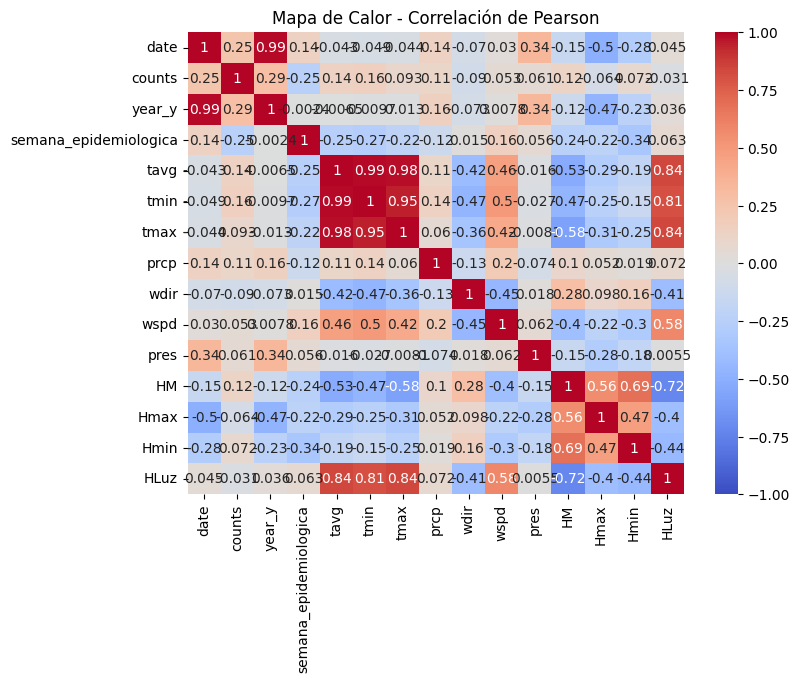

In [ ]:
correlation_matrix = result.corr(method='pearson')

# 3. Crear el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Mapa de Calor - Correlación de Pearson')
plt.show()

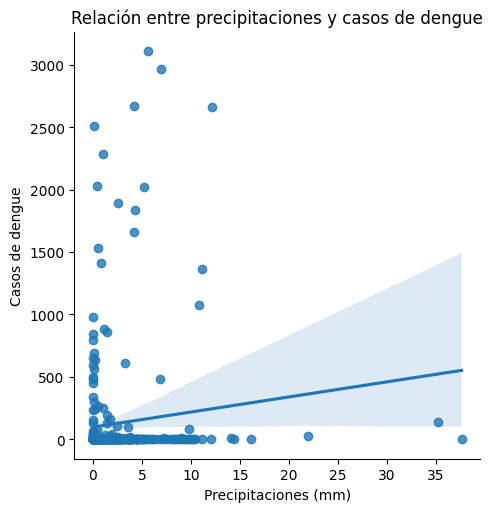

In [ ]:
import seaborn as sns

sns.lmplot(x='prcp', y='counts', data=result)
plt.title('Relación entre precipitaciones y casos de dengue')
plt.xlabel('Precipitaciones (mm)')
plt.ylabel('Casos de dengue')
plt.show()

In [ ]:
result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ds                     365 non-null    datetime64[ns]
 1   year_y                 365 non-null    category      
 2   semana_epidemiologica  365 non-null    category      
 3   HM                     365 non-null    float64       
 4   Hmax                   365 non-null    float64       
 5   Hmin                   365 non-null    float64       
 6   horas luz              365 non-null    float64       
 7   y                      365 non-null    float64       
 8   tavg                   365 non-null    float64       
 9   tmin                   365 non-null    float64       
 10  tmax                   365 non-null    float64       
 11  prcp                   365 non-null    float64       
 12  wdir                   365 non-null    float64       
 13  wspd 

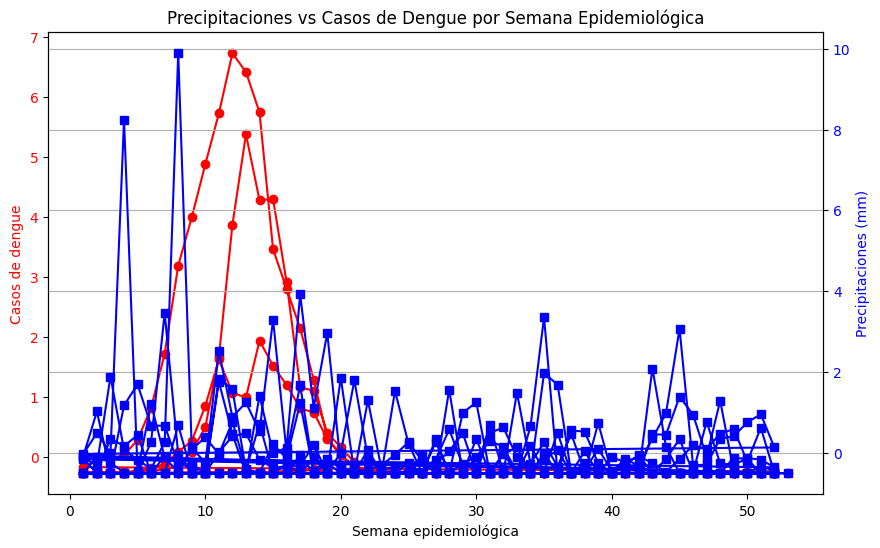

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Primer eje: casos de dengue
ax1.plot(result['semana_epidemiologica'], result['y'], color='red', marker='o', label='Casos de dengue')
ax1.set_ylabel('Casos de dengue', color='red')
ax1.tick_params(axis='y', labelcolor='red')
ax1.set_xlabel('Semana epidemiológica')

# Segundo eje: precipitaciones
ax2 = ax1.twinx()
ax2.plot(result['semana_epidemiologica'], result['prcp'], color='blue', marker='s', label='Precipitaciones')
ax2.set_ylabel('Precipitaciones (mm)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title('Precipitaciones vs Casos de Dengue por Semana Epidemiológica')
plt.grid(True)
plt.show()

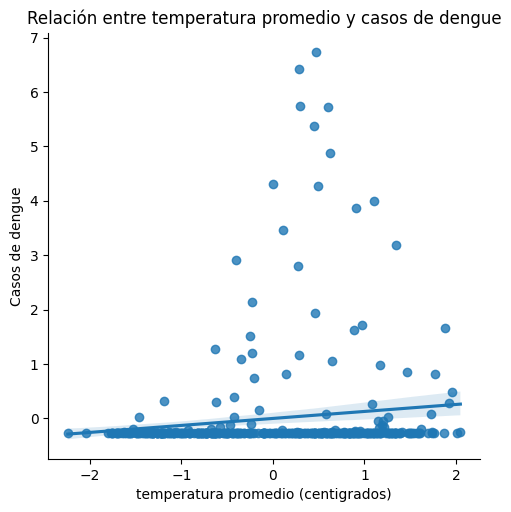

In [ ]:
sns.lmplot(x='tavg', y='y', data=result)
plt.title('Relación entre temperatura promedio y casos de dengue')
plt.xlabel('temperatura promedio (centigrados)')
plt.ylabel('Casos de dengue')
plt.show()

In [ ]:
resultoriginal = pd.read_excel ("/content/result.xlsx")
result25original = pd.read_excel("/content/result25.xlsx")

In [ ]:
resultoriginal = resultoriginal.drop(columns=['prcplag_1', 'prcplag_2', 'prcplag_3',
                                              'tavglag_1', 'tavglag_2',  'HMlag_1'])
# 'countslag_1', 'countslag_2', 'countslag_3',


In [ ]:
resultoriginal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 362 entries, 0 to 361
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ds                     362 non-null    datetime64[ns]
 1   y                      362 non-null    int64         
 2   year_y                 362 non-null    int64         
 3   semana_epidemiologica  362 non-null    int64         
 4   tavg                   362 non-null    float64       
 5   tmin                   362 non-null    float64       
 6   tmax                   362 non-null    float64       
 7   prcp                   362 non-null    float64       
 8   wdir                   362 non-null    float64       
 9   wspd                   362 non-null    float64       
 10  pres                   362 non-null    float64       
 11  HM                     362 non-null    int64         
 12  Hmax                   362 non-null    int64         
 13  Hmin 

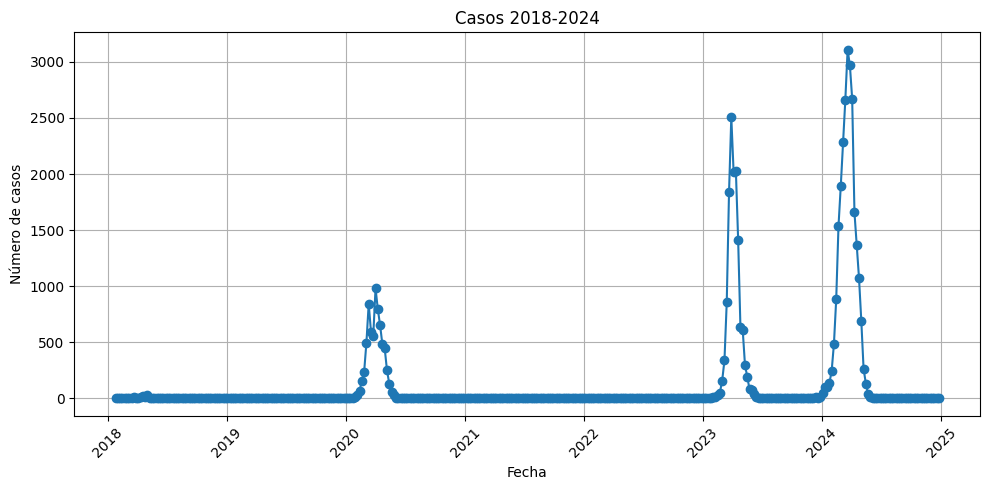

In [ ]:

# Crear el gráfico
plt.figure(figsize=(10, 5))  # tamaño opcional
plt.plot(resultoriginal["ds"], resultoriginal["y"], marker='o', linestyle='-')  # gráfico de líneas con puntos
plt.title("Casos 2018-2024")
plt.xlabel("Fecha")
plt.ylabel("Número de casos")
plt.grid(True)
plt.xticks(rotation=45)  # gira las fechas para que no se solapen
plt.tight_layout()       # mejora el espaciado automático
plt.show()

#prediccion con la base completa de casos y clima

Estandarizar los datos en Python significa transformar las variables para que tengan media = 0 y desviación estándar = 1, lo cual es útil en muchos algoritmos de machine learning.
Si vas a usar el modelo con nuevos datos después, guarda el scaler con joblib o pickle.

In [ ]:
result=pd.read_excel ('/content/result.xlsx')

In [ ]:
#transformo year y semana_epidemiologica a categoría así no se estandariza los resultados

result['year_y'] = result['year_y'].astype('category')
result['semana_epidemiologica'] = result['semana_epidemiologica'].astype('category')

# result['counts'] =  result['counts'].astype ("category") # NO PARA PROPHET

In [ ]:
result.dtypes

,0
ds,datetime64[ns]
y,int64
year_y,category
semana_epidemiologica,category
tavg,float64
tmin,float64
tmax,float64
prcp,float64
wdir,float64
wspd,float64


In [ ]:
#### 2025 ####

result25= pd.read_excel("/content/result25.xlsx")

In [ ]:
result25 = result25.drop(columns=['Unnamed: 0'])

In [ ]:
from os import rename
result25 = result25. rename(columns={'year': 'year_y'})

In [ ]:
result25 = result25.rename(columns={'date': 'ds',
                        'counts': 'y'})

In [ ]:
result25['year_y'] = result25['year_y'].astype('category')
result25['semana_epidemiologica'] = result25['semana_epidemiologica'].astype('category')
# result['counts'] =  result['counts'].astype ("category") # NO PARA PROPHET

In [ ]:
#Agrego los lags en Result
result['countslag_1'] = result['y'].shift(1)
result['countslag_2'] = result['y'].shift(2)
result['countslag_3'] = result['y'].shift(3)

result['prcplag_1'] =result ['prcp'].shift(1)
result['prcplag_2'] = result['prcp'].shift(2)
result['prcplag_3'] = result['prcp'].shift(3)

result['tavglag_2'] = result['tavg'].shift(2)
result['tavglag_1'] = result['tavg'].shift(1)

result['HMlag_1'] = result['HM'].shift(1)

In [ ]:
### Agrego los lags en Result2025

# Crear lags casos de dengue ppc y humedad temperatura (prc Temperatura y humedad usa en los modelos)

result25['countslag_1'] = result25['counts'].shift(1)
result25['countslag_2'] = result25['counts'].shift(2)
result25['countslag_3'] = result25['counts'].shift(3)
# result25['countslag_4'] = result25['counts'].shift(4)
# result25['countslag_8'] = result25['counts'].shift(8)

#SON LOS Q AGREGUÉ EN PROPHET

result25['prcplag_1'] =result25 ['prcp'].shift(1)
result25['prcplag_2'] = result25['prcp'].shift(2)
result25['prcplag_3'] = result25['prcp'].shift(3)

result25['tavglag_2'] = result25['tavg'].shift(2)
result25['tavglag_1'] = result25['tavg'].shift(1)

result25['HMlag_1'] = result25['HM'].shift(1)


In [ ]:
result.head()

,date,counts,year_y,semana_epidemiologica,tavg,tmin,tmax,prcp,wdir,wspd,...,HM,Hmax,Hmin,HLuz,prcplag_1,prcplag_2,prcplag_3,tavglag_2,tavglag_1,HMlag_1
3,2018-01-24,0,2018,4,24.685714,21.314286,30.200000,0.071429,83.857143,16.914286,...,61,99,24,14.2,2.471429,0.000000,0.000000,26.971429,23.942857,61.0
4,2018-01-31,1,2018,5,25.728571,22.228571,30.371429,0.000000,73.571429,17.714286,...,61,99,24,14.2,0.071429,2.471429,0.000000,23.942857,24.685714,61.0
5,2018-02-07,2,2018,6,26.557143,23.183333,31.500000,3.000000,60.000000,11.071429,...,64,98,30,13.3,0.000000,0.071429,2.471429,24.685714,25.728571,61.0
6,2018-02-14,0,2018,7,22.942857,19.100000,27.128571,16.142857,81.000000,16.228571,...,64,98,30,13.3,3.000000,0.000000,0.071429,25.728571,26.557143,64.0
7,2018-02-21,3,2018,8,24.014286,20.128571,28.271429,1.857143,103.333333,13.042857,...,64,98,30,13.3,16.142857,3.000000,0.000000,26.557143,22.942857,64.0


In [ ]:
result25.head() ## OJO tengo datos nulos por los lags, no los borré porq borro muchos datos

,date,counts,year_y,semana_epidemiologica,tavg,tmin,tmax,prcp,wdir,wspd,...,HM,Hmax,Hmin,HLuz,prcplag_1,prcplag_2,prcplag_3,tavglag_2,tavglag_1,HMlag_1
3,2025-01-27,0,2025,4,25.457143,21.485714,29.428571,7.328571,174.714286,15.528571,...,60.000000,98.000000,18.000000,14.200000,0.328571,0.000000,0.557143,23.357143,25.942857,60.000000
4,2025-02-03,1,2025,5,25.542857,21.428571,28.300000,0.600000,71.285714,17.171429,...,61.285714,97.714286,18.857143,14.071429,7.328571,0.328571,0.000000,25.942857,25.457143,60.000000
5,2025-02-10,4,2025,6,26.228571,22.742857,30.128571,4.685714,59.714286,13.600000,...,69.000000,96.000000,24.000000,13.300000,0.600000,7.328571,0.328571,25.457143,25.542857,61.285714
6,2025-02-17,7,2025,7,24.485714,19.442857,29.885714,2.714286,76.285714,17.957143,...,69.000000,96.000000,24.000000,13.300000,4.685714,0.600000,7.328571,25.542857,26.228571,69.000000
7,2025-02-24,4,2025,8,24.157143,19.985714,28.585714,0.371429,77.571429,13.057143,...,69.000000,96.000000,24.000000,13.300000,2.714286,4.685714,0.600000,26.228571,24.485714,69.000000


In [ ]:
result25.dropna(inplace=True)

In [ ]:
result.dropna(inplace=True)

In [ ]:
result.to_excel("resultconlags.xlsx")
result25.to_excel("result25conlags.xlsx")

# PROPHET



In [ ]:
result = pd.read_excel ("/content/resultconlags.xlsx")
result25 = pd.read_excel("/content/result25conlags.xlsx")

In [ ]:
#cambio los nombres de las columnas date a 'ds' y counts a 'y' porq así lo pide prophet

result = result.rename(columns={'date': 'ds',
                        'counts': 'y'})

result.head()

,ds,y,year_y,semana_epidemiologica,tavg,tmin,tmax,prcp,wdir,wspd,...,HLuz,prcplag_1,prcplag_2,prcplag_3,tavglag_2,tavglag_1,HMlag_1,countslag_1,countslag_2,countslag_3
0,2018-02-14,0,2018,7,22.942857,19.100000,27.128571,16.142857,81.000000,16.228571,...,13.3,3.000000,0.000000,0.071429,25.728571,26.557143,64,2,1,0
1,2018-02-21,3,2018,8,24.014286,20.128571,28.271429,1.857143,103.333333,13.042857,...,13.3,16.142857,3.000000,0.000000,26.557143,22.942857,64,0,2,1
2,2018-02-28,5,2018,9,24.400000,21.957143,27.485714,0.000000,82.571429,17.414286,...,13.3,1.857143,16.142857,3.000000,22.942857,24.014286,64,3,0,2
3,2018-03-07,5,2018,10,24.285714,20.500000,29.142857,0.000000,67.714286,13.771429,...,12.2,0.000000,1.857143,16.142857,24.014286,24.400000,64,5,3,0
4,2018-03-14,6,2018,11,21.700000,16.985714,27.457143,2.357143,120.600000,11.885714,...,12.2,0.000000,0.000000,1.857143,24.400000,24.285714,65,5,5,3


In [ ]:
# HIPERPARÁMETROS (LOS TUNEO SIN agregar LOS REGRESSORS al modelo, pero el dataset tiene todas las variables)

param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
    'holidays_prior_scale': [0.01, 0.1, 1.0, 10.0]
}

# Generate all combinations of parameters
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
rmses = []  # Store the RMSEs for each params here

# Use cross validation to evaluate all parameters
for params in all_params:
    m = Prophet(**params).fit(result)  # Fit model with given params
    df_cv = cross_validation(m, horizon='182 days', parallel="processes")   #, cutoffs=cutoffs
    df_p = performance_metrics(df_cv, rolling_window=1)
    rmses.append(df_p['rmse'].values[0])


In [ ]:
# Find the best parameters
tuning_results = pd.DataFrame(all_params)
tuning_results['rmse'] = rmses
tuning_results.sort_values('rmse')
print(tuning_results)


    changepoint_prior_scale  seasonality_prior_scale  holidays_prior_scale  \
0                     0.001                     0.01                  0.01   
1                     0.001                     0.01                  0.10   
2                     0.001                     0.01                  1.00   
3                     0.001                     0.01                 10.00   
4                     0.001                     0.10                  0.01   
..                      ...                      ...                   ...   
59                    0.500                     1.00                 10.00   
60                    0.500                    10.00                  0.01   
61                    0.500                    10.00                  0.10   
62                    0.500                    10.00                  1.00   
63                    0.500                    10.00                 10.00   

          rmse  
0   485.614066  
1   485.614066  
2   485.6140

In [ ]:
tuning_results.to_excel("tuning_resultsFINAL.xlsx")

In [ ]:
# MODELO3 hiperparamentros con datos sin estandarizar y con LAGS MODEL3
# rmse = 472.6
# changepoint_prior_scale =0.001
## seasonality_prior_scale = 1
#  holidays_prior_scale  = 0.01

In [ ]:
# MODELO 4 Entrenar el modelo sin estandarizar con todos los lags
# rmse = 473.8
# changepoint_prior_scale =0.001
# seasonality_prior_scale = 10
#  holidays_prior_scale  = 0.01



In [ ]:
#NO LE AGREGUÉ LOS REGRESORES COLINEALES (HMAX,HMIN,TMIN.TMAX,PRES)

model3= Prophet(weekly_seasonality=True, interval_width=0.95, changepoint_prior_scale =0.001,
seasonality_prior_scale = 1 ,
holidays_prior_scale  = 0.01      )


In [ ]:
model3.add_regressor('prcp', standardize=False)
model3.add_regressor('tavg', standardize=False)
model3.add_regressor('HM', standardize=False)
model3.add_regressor('HLuz', standardize=False)
model3.add_regressor('wdir', standardize=False)
model3.add_regressor('wspd', standardize=False)

model3.add_regressor('prcplag_1', standardize=False)
model3.add_regressor('prcplag_2', standardize=False)
model3.add_regressor('prcplag_3', standardize=False)
model3.add_regressor('tavglag_2', standardize=False)
model3.add_regressor('tavglag_1', standardize=False)
model3.add_regressor('HMlag_1', standardize=False)
model3.add_regressor('countslag_1', standardize=False)
model3.add_regressor('countslag_2', standardize=False)
model3.add_regressor('countslag_3', standardize=False)

model3.fit(result)


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpwtu_cv6f/wvrksl74.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpwtu_cv6f/u4olu665.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=1576', 'data', 'file=/tmp/tmpwtu_cv6f/wvrksl74.json', 'init=/tmp/tmpwtu_cv6f/u4olu665.json', 'output', 'file=/tmp/tmpwtu_cv6f/prophet_modelznjail8g/prophet_model-20250704171045.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
17:10:45 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
17:10:45 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
model4= Prophet(weekly_seasonality=True, interval_width=0.95, changepoint_prior_scale =0.001,
seasonality_prior_scale = 10 ,
holidays_prior_scale  = 0.01      )

In [ ]:
model4.add_regressor('prcp', standardize=False)
model4.add_regressor('tavg', standardize=False)
model4.add_regressor('HM', standardize=False)
model4.add_regressor('HLuz', standardize=False)
model4.add_regressor('wdir', standardize=False)
model4.add_regressor("Hmax", standardize=False)
model4.add_regressor("Hmin", standardize=False)
model4.add_regressor("tmin", standardize=False)
model4.add_regressor("tmax", standardize=False)
model4.add_regressor( "pres", standardize=False)

model4.add_regressor('prcplag_1', standardize=False)
model4.add_regressor('prcplag_2', standardize=False)
model4.add_regressor('prcplag_3', standardize=False)
model4.add_regressor('tavglag_2', standardize=False)
model4.add_regressor('tavglag_1', standardize=False)
model4.add_regressor('HMlag_1', standardize=False)
model4.add_regressor('countslag_1', standardize=False)
model4.add_regressor('countslag_2', standardize=False)
model4.add_regressor('countslag_3', standardize=False)


model4.fit(result)



INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpwtu_cv6f/ftc_ucoo.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpwtu_cv6f/4qbbq7cn.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=85411', 'data', 'file=/tmp/tmpwtu_cv6f/ftc_ucoo.json', 'init=/tmp/tmpwtu_cv6f/4qbbq7cn.json', 'output', 'file=/tmp/tmpwtu_cv6f/prophet_modelmfgg7prz/prophet_model-20250704165136.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
16:51:36 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
16:51:36 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
#6 años máximo para entrenar

result_cv63 = cross_validation(
    model3,
    initial='2191 days',   # 6 años, el 2020 tiene 53 semanas
    period=' 28 days',     # cada cuánto se mueve la ventana 1 mes
    horizon=' 84 days',     # cuánto tiempo predice hacia adelante 3 meses
    parallel="processes"
)

INFO:prophet:Making 9 forecasts with cutoffs between 2024-02-21 00:00:00 and 2024-10-02 00:00:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x77fc0eb88410>
DEBUG:cmdstanpy:input tempfile: /tmp/tmplmpq11t8/u8z_jqkn.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplmpq11t8/383545v6.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplmpq11t8/ypo8rbew.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplmpq11t8/jnsflw75.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=42537', 'data', 'file=/tmp/tmplmpq11t8/383545v6.json', 'init=/tmp/tmplmpq11t8/ypo8rbew.json', 'output', 'file=/tmp/tmplmpq11t8/prophet_modelgvb8mvg4/prophet_model-20250629201352.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args:

In [ ]:
result_cv64 = cross_validation(
    model4,
    initial='2191 days',   # 6 años, el 2020 tiene 53 semanas
    period=' 28 days',     # cada cuánto se mueve la ventana 1 mes
    horizon=' 84 days',     # cuánto tiempo predice hacia adelante 3 meses
    parallel="processes"
)

INFO:prophet:Making 9 forecasts with cutoffs between 2024-02-21 00:00:00 and 2024-10-02 00:00:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x7a811af1aed0>
DEBUG:cmdstanpy:input tempfile: /tmp/tmpwtu_cv6f/xshyjrmq.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpwtu_cv6f/s2di4n0m.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpwtu_cv6f/pn7manny.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpwtu_cv6f/hx8hgcug.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=48620', 'data', 'file=/tmp/tmpwtu_cv6f/xshyjrmq.json', 'init=/tmp/tmpwtu_cv6f/pn7manny.json', 'output', 'file=/tmp/tmpwtu_cv6f/prophet_model3p539x7f/prophet_model-20250704165241.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
DEBUG:cmdstanpy:idx 0
16:52:41 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1

In [ ]:
from prophet.diagnostics import performance_metrics
from prophet.plot import plot_cross_validation_metric


In [ ]:
result_cv4

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2022-03-24 00:00:00,0.106952,-0.489931,0.611575,-0.276311,2022-03-23 12:00:00
1,2022-03-31 00:00:00,0.147456,-0.365562,0.686034,-0.276311,2022-03-23 12:00:00
2,2022-04-07 00:00:00,0.175393,-0.377776,0.722448,-0.276311,2022-03-23 12:00:00
3,2022-04-14 00:00:00,0.138014,-0.419644,0.666501,-0.276311,2022-03-23 12:00:00
4,2022-04-21 00:00:00,0.091505,-0.388777,0.625113,-0.274055,2022-03-23 12:00:00
...,...,...,...,...,...,...
404,2024-11-28 00:00:00,0.296421,-1.322366,1.941695,-0.276311,2024-10-02 12:00:00
405,2024-12-05 00:00:00,0.225229,-1.293353,1.759841,-0.276311,2024-10-02 12:00:00
406,2024-12-12 00:00:00,0.199828,-1.306029,1.689020,-0.274055,2024-10-02 12:00:00
407,2024-12-19 00:00:00,0.150795,-1.324407,1.769432,-0.276311,2024-10-02 12:00:00


In [ ]:
df_metrics = performance_metrics(result_cv4)
# print(df_metrics.head())
df_metrics

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,7 days 12:00:00,2.109001,1.452240,0.686669,1.071721,0.886359,1.179530,0.907353
1,14 days 12:00:00,1.916383,1.384335,0.669707,0.961980,0.854106,1.165405,0.886765
2,21 days 12:00:00,1.764828,1.328468,0.652968,0.915460,0.917297,1.098095,0.857353
3,28 days 12:00:00,2.078401,1.441666,0.700877,1.596756,0.809147,1.088310,0.852941
4,35 days 12:00:00,2.282162,1.510683,0.727419,1.162642,0.936230,1.221802,0.852941
5,42 days 12:00:00,1.979181,1.406834,0.696014,1.017813,0.918010,1.200189,0.852941
6,49 days 12:00:00,1.814571,1.347060,0.678556,0.974980,0.923556,1.142199,0.852941
7,56 days 12:00:00,2.143286,1.463997,0.729534,1.502859,0.813168,1.164536,0.852941
8,63 days 12:00:00,2.357253,1.535335,0.753590,1.172703,0.967409,1.240391,0.852941
9,70 days 12:00:00,2.058729,1.434827,0.720938,1.060482,0.894775,1.214949,0.852941


In [ ]:
#con datos sin estandarizar model3

df_metrics3 = performance_metrics(result_cv63)
print(df_metrics3[['horizon', 'rmse', 'mae']].head())

INFO:prophet:Skipping MAPE because y close to 0


  horizon        rmse         mae
0 14 days  182.070768   78.173990
1 21 days  406.310751  227.942103
2 28 days  239.754871  131.839593
3 35 days  316.921836  184.210382
4 42 days  435.406090  206.215944


In [ ]:
df_metrics4 = performance_metrics(result_cv64)
print(df_metrics4[['horizon', 'rmse', 'mae']].head())

INFO:prophet:Skipping MAPE because y close to 0


  horizon        rmse         mae
0 14 days  144.450139   67.889205
1 21 days  257.993219  144.918377
2 28 days  199.572297  117.807130
3 35 days  190.874406  106.111995
4 42 days  373.926446  194.315412


/usr/local/lib/python3.11/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.11/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


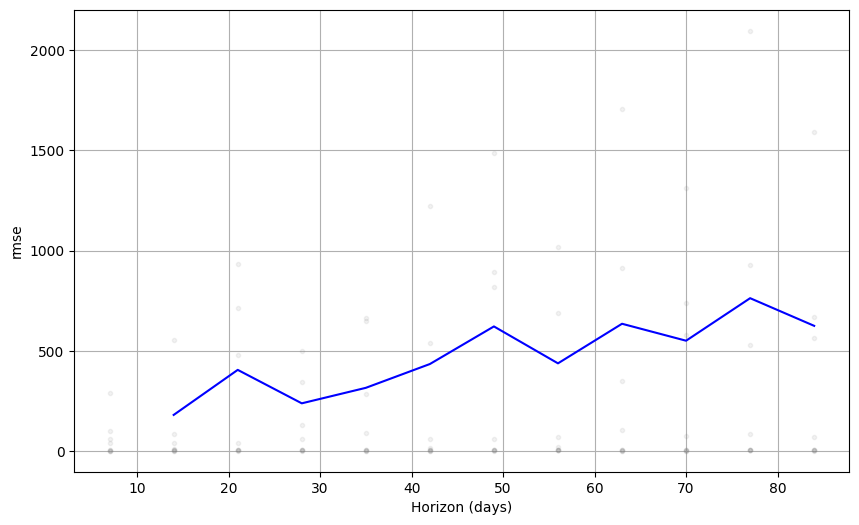

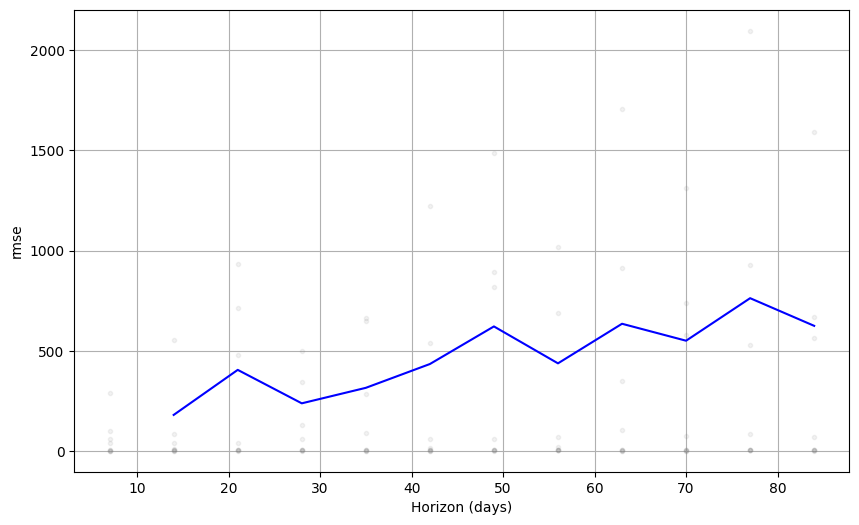

In [ ]:
plot_cross_validation_metric(result_cv63, metric='rmse')

/usr/local/lib/python3.11/dist-packages/prophet/plot.py:546: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.11/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


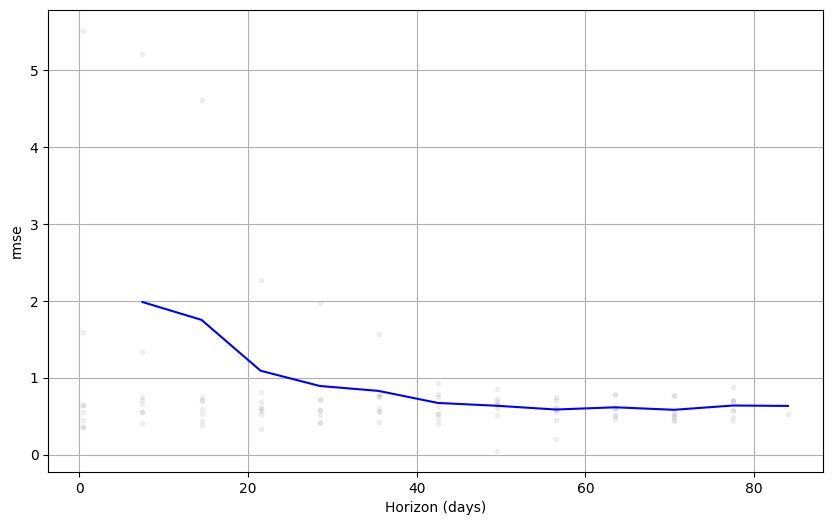

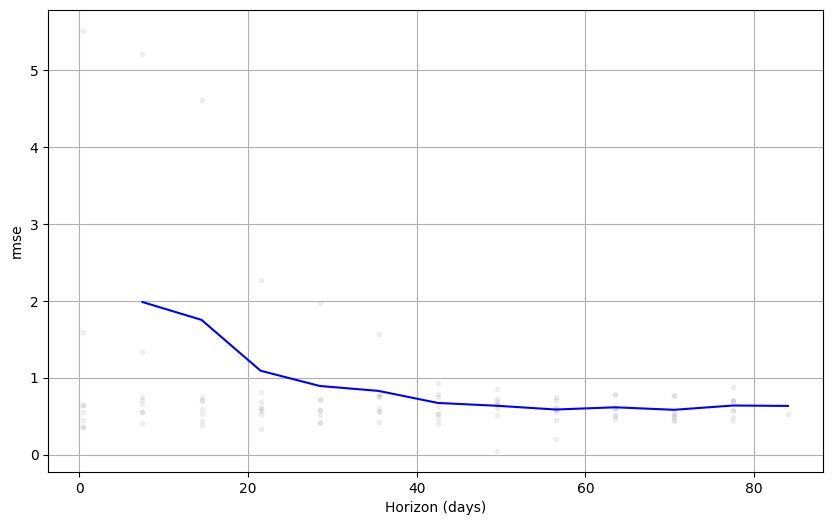

In [ ]:
plot_cross_validation_metric(result_cv64, metric='rmse') # con datos estandarizados

/usr/local/lib/python3.11/dist-packages/prophet/plot.py:546: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.11/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


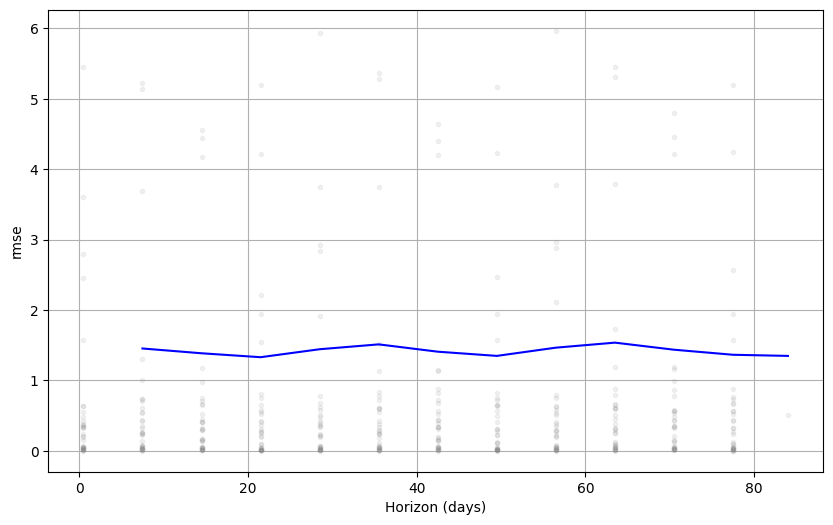

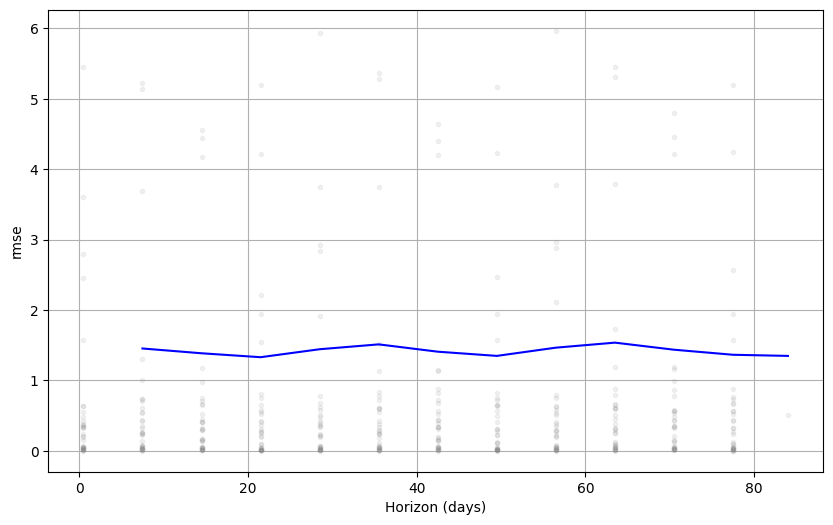

In [ ]:
plot_cross_validation_metric(result_cv4, metric='rmse')

In [ ]:
model.params['beta']

array([[ 3.52632e-04, -1.48998e-02,  5.83175e-03, -1.36261e-03,
         2.35126e-04, -6.54531e-03, -6.58517e-03, -2.49067e-03,
        -2.31860e-03,  4.34608e-03,  3.01740e-03,  1.64705e-03,
        -7.48973e-04, -3.79984e-03, -2.34272e-03, -1.51853e-04,
        -1.63072e-03,  3.01544e-03,  3.31409e-03,  2.02357e-03,
         1.10194e-02, -8.78765e-03,  1.37409e-02,  3.13628e-03,
         6.11529e-03,  1.26985e-02, -3.13780e-04,  1.95212e-03,
        -3.03510e-04, -3.57223e-03,  1.76533e-05,  1.36094e-03,
         1.32940e-04, -7.35045e-04,  5.64263e-05, -7.39133e-04,
         2.59591e-03,  3.46636e-04,  4.24771e-04, -8.45697e-05,
        -5.05256e-05]])

In [ ]:
# result25 = result25.rename(columns={'horas luz': 'HLuz'})
result25.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ds                     20 non-null     datetime64[ns]
 1   year_y                 20 non-null     category      
 2   semana_epidemiologica  20 non-null     category      
 3   y                      20 non-null     float64       
 4   tavg                   20 non-null     float64       
 5   tmin                   20 non-null     float64       
 6   tmax                   20 non-null     float64       
 7   prcp                   20 non-null     float64       
 8   wdir                   20 non-null     float64       
 9   wspd                   20 non-null     float64       
 10  pres                   20 non-null     float64       
 11  HM                     20 non-null     float64       
 12  Hmax                   20 non-null     float64       
 13  Hmin   

###predecir en 2025

In [ ]:
forecast3 = model3.predict(result25)
forecast3[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()

,ds,yhat,yhat_lower,yhat_upper
0,2025-01-27,7.095043,-6151.771617,6306.002088
1,2025-02-03,5.678938,-5996.545264,6330.038404
2,2025-02-10,6.810251,-6016.543553,5796.240721
3,2025-02-17,11.146663,-6202.714726,6731.210613
4,2025-02-24,14.698555,-5691.610376,5640.379626


In [ ]:
columnas_deseadas = ["ds", "y", "semana_epidemiologica"]
predprophet = result25[columnas_deseadas]
predprophet

,ds,y,semana_epidemiologica
0,2025-01-27,0,4
1,2025-02-03,1,5
2,2025-02-10,4,6
3,2025-02-17,7,7
4,2025-02-24,4,8
5,2025-03-03,1,9
6,2025-03-10,9,10
7,2025-03-17,20,11
8,2025-03-24,17,12
9,2025-03-31,17,13


In [ ]:
columnas_deseadasforecast = ["yhat"]
forecast33 = forecast3[columnas_deseadasforecast]
u3 = pd. concat([predprophet, forecast33], axis=1)
u3

,ds,y,semana_epidemiologica,yhat
0,2025-01-27,0,4,7.095043
1,2025-02-03,1,5,5.678938
2,2025-02-10,4,6,6.810251
3,2025-02-17,7,7,11.146663
4,2025-02-24,4,8,14.698555
5,2025-03-03,1,9,10.528247
6,2025-03-10,9,10,5.215875
7,2025-03-17,20,11,14.967068
8,2025-03-24,17,12,30.662476
9,2025-03-31,17,13,26.056756


In [ ]:
columnas_deseadasforecast = ["yhat", "yhat_lower", "yhat_upper"]
forecast44 = forecast4[columnas_deseadasforecast]
forecast44

,yhat,yhat_lower,yhat_upper
0,12.517104,-6263.812022,5995.521776
1,17.571520,-5958.520740,5925.318249
2,19.169763,-6009.239624,5973.803339
3,22.184830,-6152.610334,5612.264819
4,25.709860,-5788.367953,5845.048583
5,17.739336,-5785.188590,6522.447475
6,15.810190,-6102.565427,6276.089213
7,20.617030,-5767.385791,6353.350223
8,35.743493,-6048.290249,6178.487097
9,35.496939,-5969.475176,5738.354398


In [ ]:
u4 = pd.concat([predprophet, forecast44], axis=1)
u4

,ds,y,semana_epidemiologica,yhat,yhat_lower,yhat_upper
0,2025-01-27,0,4,12.517104,-6263.812022,5995.521776
1,2025-02-03,1,5,17.571520,-5958.520740,5925.318249
2,2025-02-10,4,6,19.169763,-6009.239624,5973.803339
3,2025-02-17,7,7,22.184830,-6152.610334,5612.264819
4,2025-02-24,4,8,25.709860,-5788.367953,5845.048583
5,2025-03-03,1,9,17.739336,-5785.188590,6522.447475
6,2025-03-10,9,10,15.810190,-6102.565427,6276.089213
7,2025-03-17,20,11,20.617030,-5767.385791,6353.350223
8,2025-03-24,17,12,35.743493,-6048.290249,6178.487097
9,2025-03-31,17,13,35.496939,-5969.475176,5738.354398


In [ ]:
forecast4 = model4.predict(result25)
forecast4[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()

,ds,yhat,yhat_lower,yhat_upper
0,2025-01-27,6.998849,-6042.392717,5936.697330
1,2025-02-03,5.540450,-5881.998011,5819.132741
2,2025-02-10,6.706207,-5846.794119,6152.229063
3,2025-02-17,11.003786,-6168.943579,5855.801139
4,2025-02-24,14.606458,-5607.971761,5666.853197


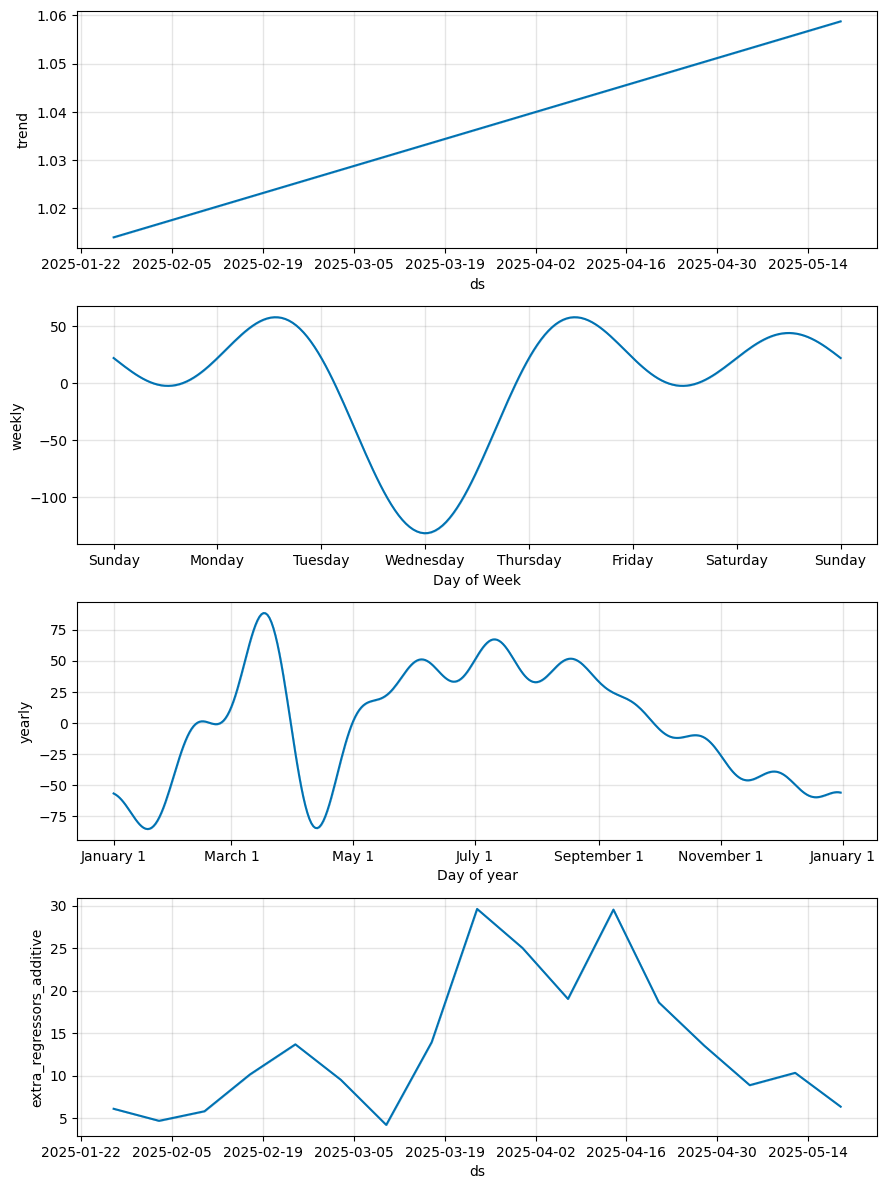

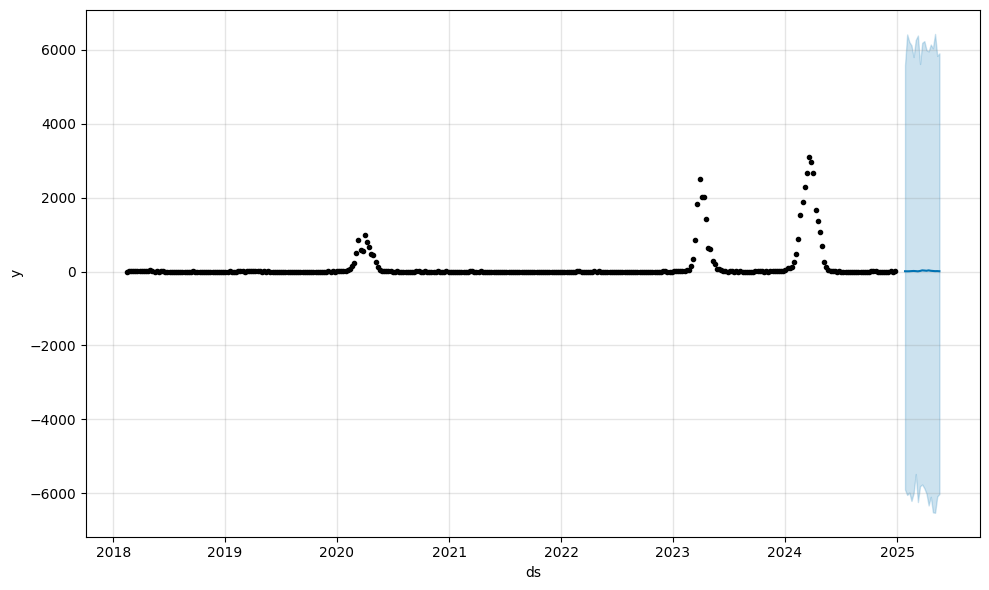

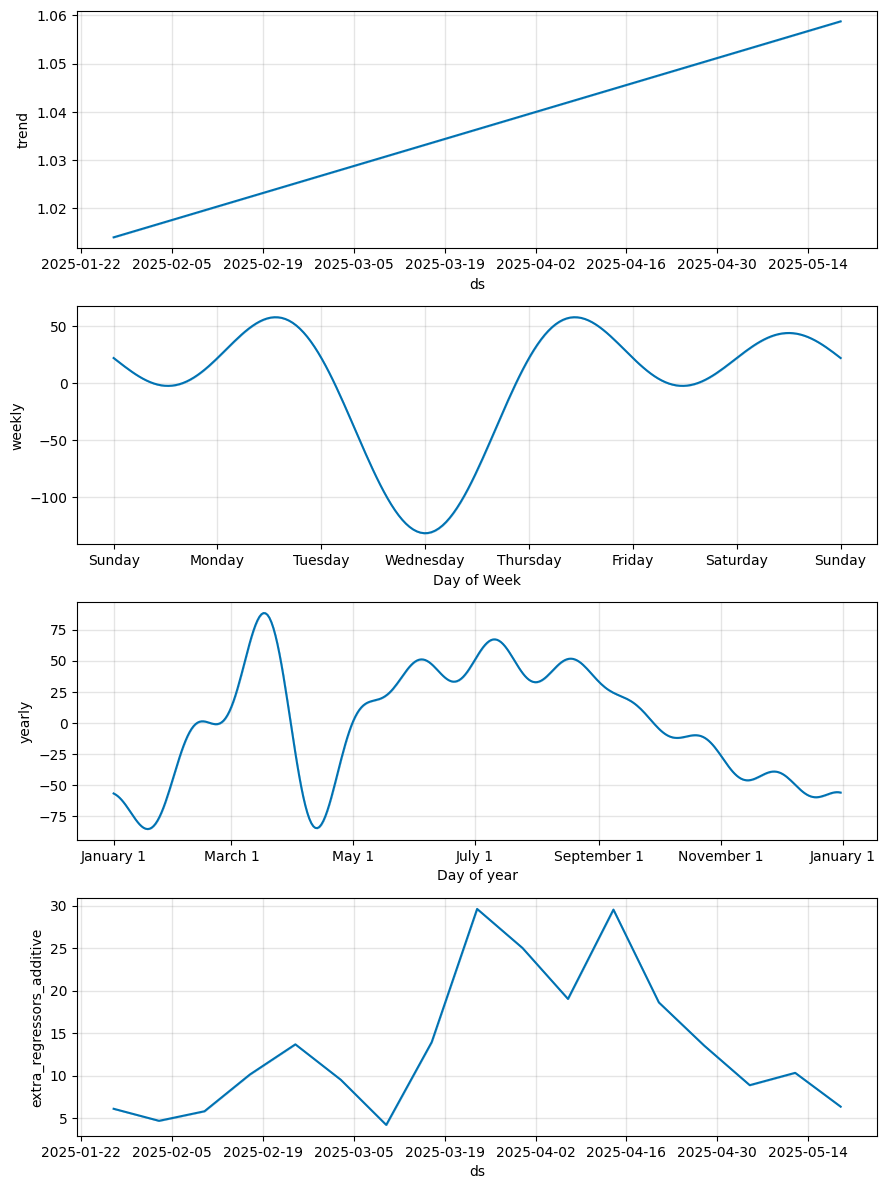

In [ ]:
model.plot(forecast3, uncertainty=True)
model.plot_components(forecast3)

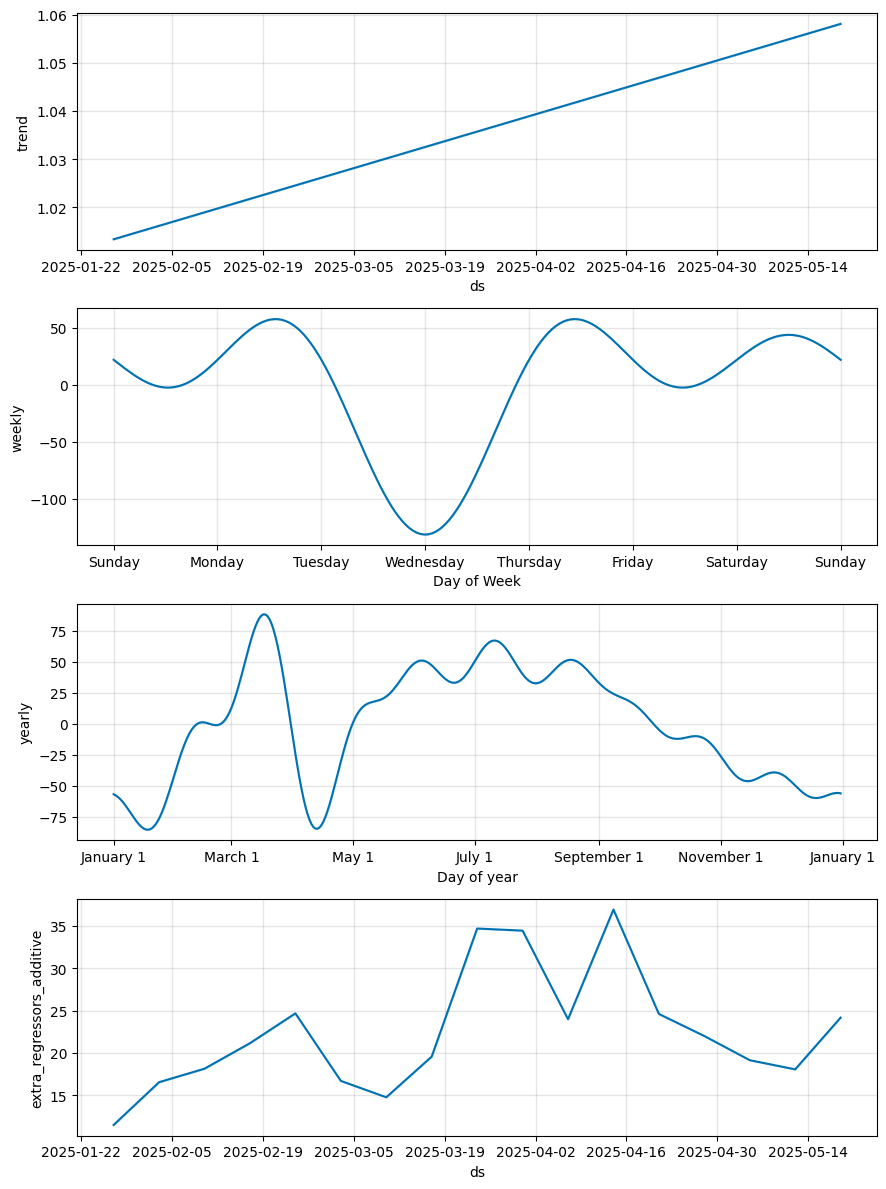

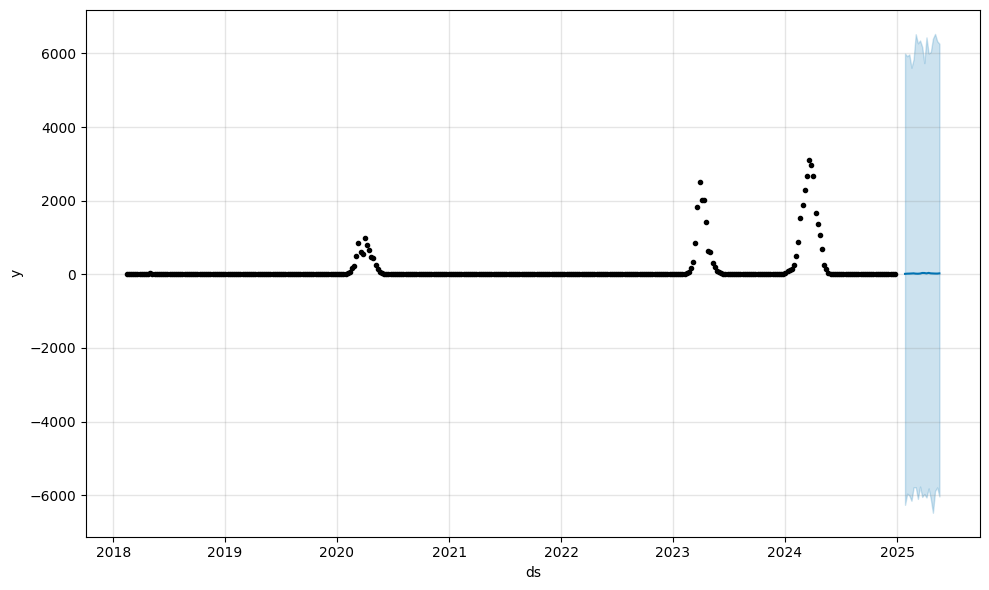

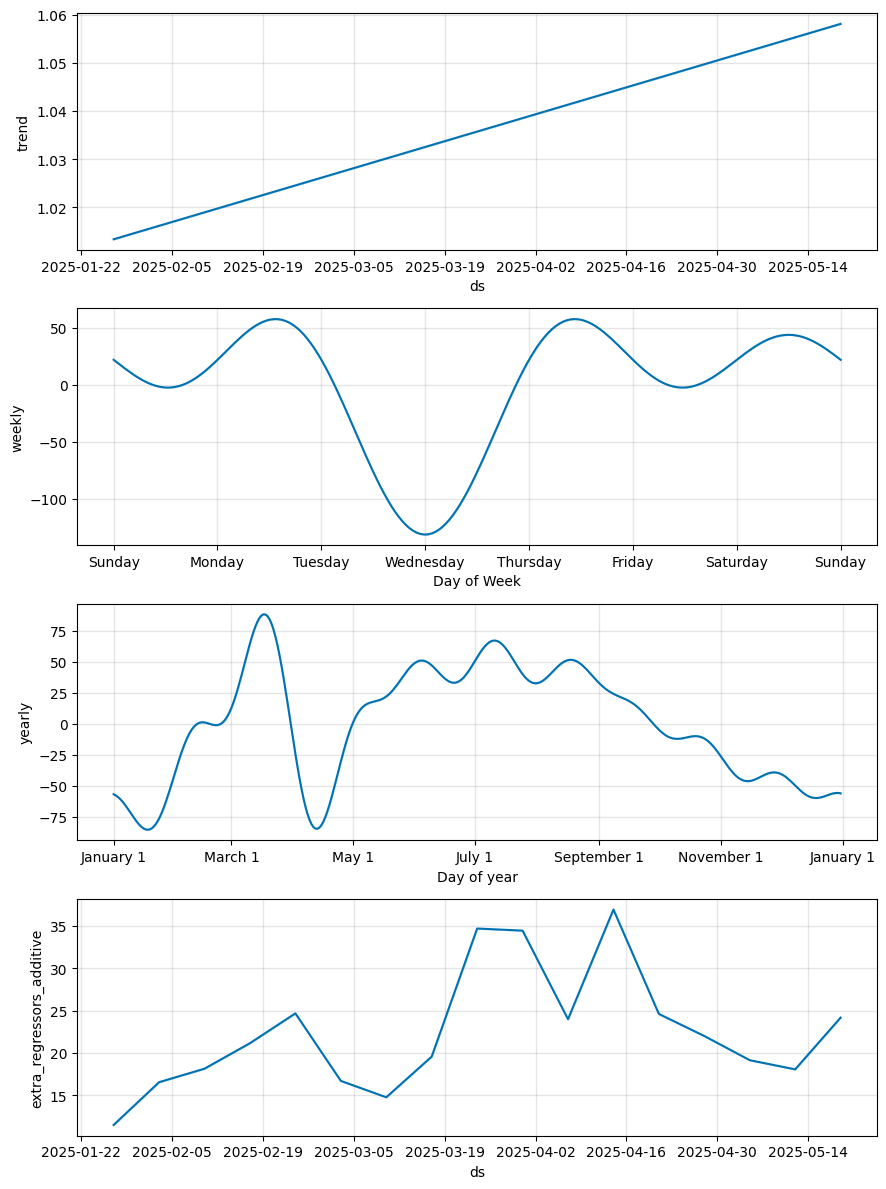

In [ ]:
model.plot(forecast4, uncertainty=True)
model.plot_components(forecast4)

In [ ]:
comparo4 = pd.concat([result25, forecast4], axis=1)
comparo4

,ds,y,year_y,semana_epidemiologica,tavg,tmin,tmax,prcp,wdir,wspd,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2025-01-27,0,2025,4,25.457143,21.485714,29.428571,7.328571,174.714286,15.528571,...,-0.000008,-0.000008,-0.000008,-0.000221,-0.000221,-0.000221,0.0,0.0,0.0,12.517104
1,2025-02-03,1,2025,5,25.542857,21.428571,28.300000,0.600000,71.285714,17.171429,...,-0.000008,-0.000008,-0.000008,0.000721,0.000721,0.000721,0.0,0.0,0.0,17.571520
2,2025-02-10,4,2025,6,26.228571,22.742857,30.128571,4.685714,59.714286,13.600000,...,-0.000008,-0.000008,-0.000008,0.001879,0.001879,0.001879,0.0,0.0,0.0,19.169763
3,2025-02-17,7,2025,7,24.485714,19.442857,29.885714,2.714286,76.285714,17.957143,...,-0.000008,-0.000008,-0.000008,0.002685,0.002685,0.002685,0.0,0.0,0.0,22.184830
4,2025-02-24,4,2025,8,24.157143,19.985714,28.585714,0.371429,77.571429,13.057143,...,-0.000008,-0.000008,-0.000008,0.003260,0.003260,0.003260,0.0,0.0,0.0,25.709860
5,2025-03-03,1,2025,9,25.185714,21.928571,27.600000,2.228571,136.142857,14.600000,...,-0.000008,-0.000008,-0.000008,0.004282,0.004282,0.004282,0.0,0.0,0.0,17.739336
6,2025-03-10,9,2025,10,25.800000,22.342857,29.528571,14.300000,81.142857,13.857143,...,-0.000008,-0.000008,-0.000008,0.005978,0.005978,0.005978,0.0,0.0,0.0,15.810190
7,2025-03-17,20,2025,11,18.900000,15.342857,22.371429,0.183333,160.714286,13.571429,...,-0.000008,-0.000008,-0.000008,0.007407,0.007407,0.007407,0.0,0.0,0.0,20.617030
8,2025-03-24,17,2025,12,24.100000,20.900000,27.871429,6.400000,169.571429,10.657143,...,-0.000008,-0.000008,-0.000008,0.007055,0.007055,0.007055,0.0,0.0,0.0,35.743493
9,2025-03-31,17,2025,13,21.771429,18.871429,25.485714,2.957143,96.714286,13.642857,...,-0.000008,-0.000008,-0.000008,0.004300,0.004300,0.004300,0.0,0.0,0.0,35.496939


<Figure size 1200x600 with 0 Axes>

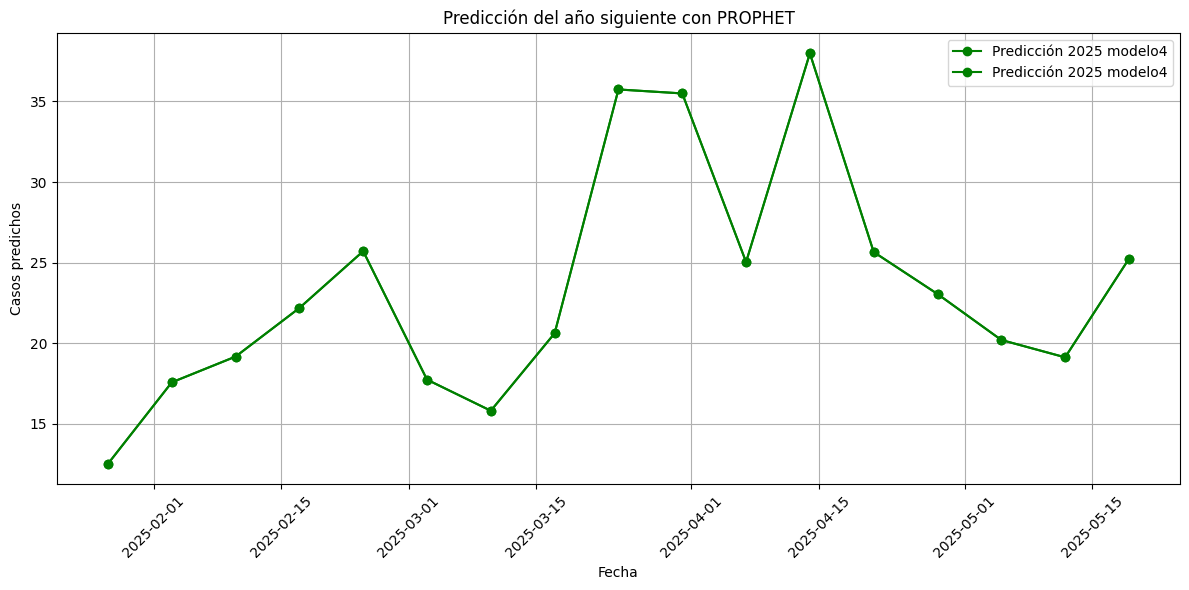

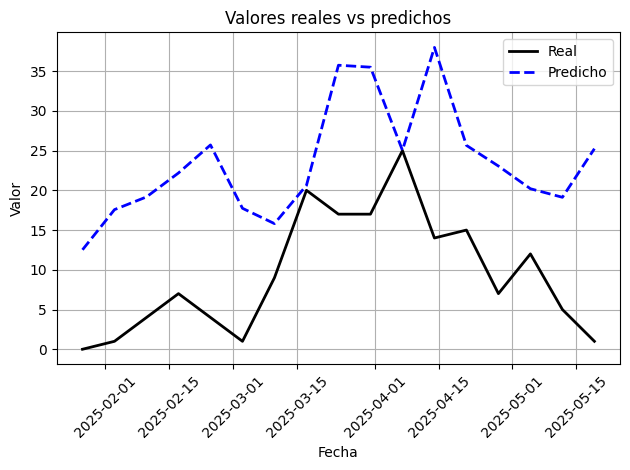

In [ ]:
#comparo4 modelo 4

plt.figure(figsize=(12, 6))

# Asegurarse de tener la columna de fechas
future_dates = comparo4['ds']
y_future_pred = comparo4['yhat']


plt.figure(figsize=(12, 6))
plt.plot(future_dates, y_future_pred, label='Predicción 2025 modelo4', color='green', marker='o')
plt.title('Predicción del año siguiente con PROPHET')
plt.xlabel('Fecha')
plt.ylabel('Casos predichos')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.plot(result25['ds'], result25['y'], label='Real', color='black', linewidth=2)
plt.plot(result25['ds'], comparo4['yhat'], label='Predicho', color='blue', linestyle='--', linewidth=2)

plt.title('Valores reales vs predichos')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
#me quedo con este modelo, no incluye las variables colineales


comparo3 = pd.concat([result25, forecast3], axis=1)
# comparo3

<Figure size 1200x600 with 0 Axes>

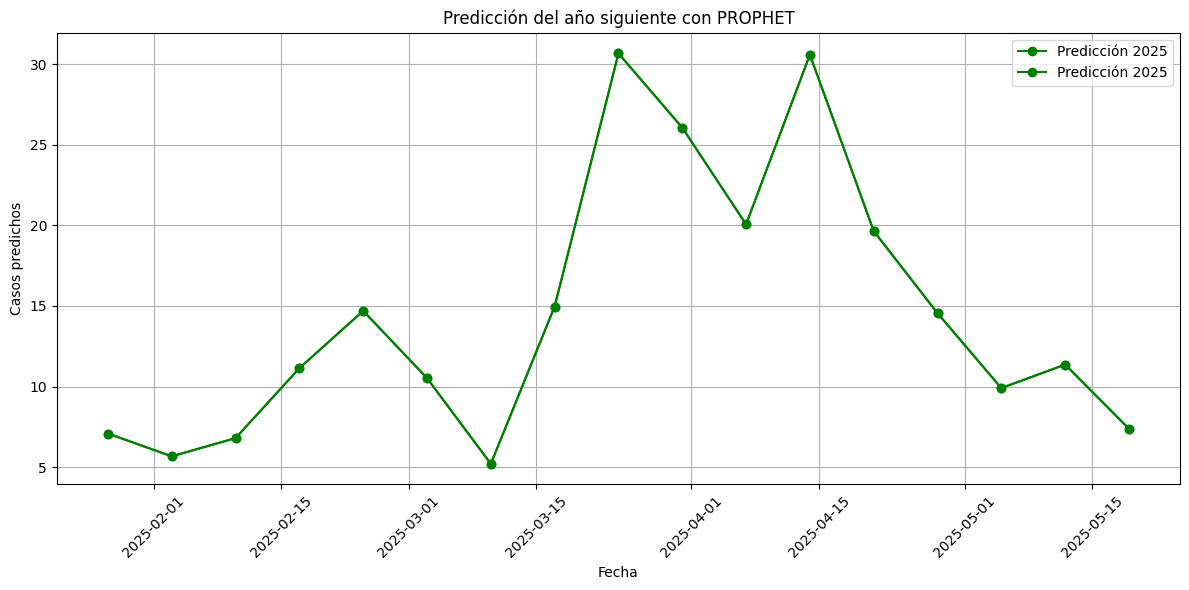

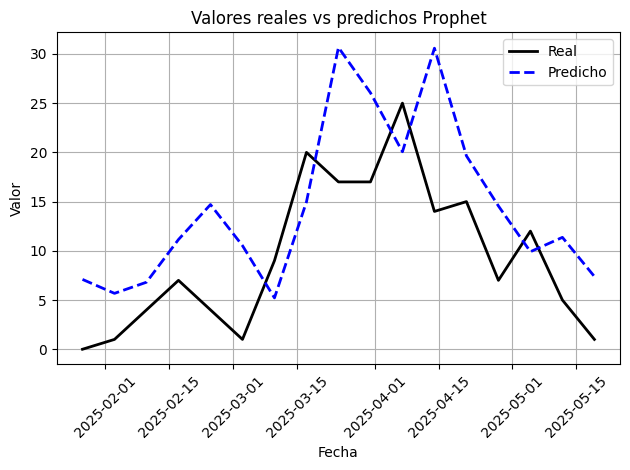

In [ ]:
#comparo3 modelo 3
plt.figure(figsize=(12, 6))

# Asegurarse de tener la columna de fechas
future_dates = comparo3['ds']
y_future_pred = comparo3['yhat']


plt.figure(figsize=(12, 6))
plt.plot(future_dates, y_future_pred, label='Predicción 2025', color='green', marker='o')
plt.title('Predicción del año siguiente con PROPHET')
plt.xlabel('Fecha')
plt.ylabel('Casos predichos')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.plot(result25['ds'], result25['y'], label='Real', color='black', linewidth=2)
plt.plot(result25['ds'], comparo3['yhat'], label='Predicho', color='blue', linestyle='--', linewidth=2)

plt.title('Valores reales vs predichos Prophet')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# MODELO 3

y_true = comparo3['y']
y_pred = comparo3['yhat']

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 7.00
RMSE: 7.95


In [ ]:
# MODELO 4

# y_true = comparo4['y']
# y_pred = comparo4['yhat']

# mae = mean_absolute_error(y_true, y_pred)
# rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# print(f"MAE: {mae:.2f}")
# print(f"RMSE: {rmse:.2f}")

MAE: 14.11
RMSE: 15.69


# XGBOOST

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [ ]:
# result=pd.read_excel ('/content/result.xlsx')

In [ ]:
result = pd.read_excel ('/content/resultconlags.xlsx') #'Unnamed: 0'

In [ ]:
#transformo year y semana_epidemiologica a categoría así no se estandariza los resultados

result['year_y'] = result['year_y'].astype('category')
result['semana_epidemiologica'] = result['semana_epidemiologica'].astype('category')
# result['counts'] =  result['counts'].astype ("category") # NO PARA PROPHET

In [ ]:
result.describe()

,ds,y,year_y,semana_epidemiologica,tavg,tmin,tmax,prcp,wdir,wspd,...,HLuz,prcplag_1,prcplag_2,prcplag_3,tavglag_2,tavglag_1,HMlag_1,countslag_1,countslag_2,countslag_3
count,359,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,...,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000
mean,2021-07-21 00:00:00,124.518106,2021.047354,26.958217,18.107043,14.461162,22.459252,2.077477,144.809325,13.896777,...,12.016156,2.085237,2.083287,2.083366,18.131198,18.121568,68.253482,124.520891,124.523677,124.520891
min,2018-02-14 00:00:00,0.000000,2018.000000,1.000000,6.971429,2.785714,11.928571,0.000000,37.857143,6.214286,...,9.900000,0.000000,0.000000,0.000000,6.971429,6.971429,56.000000,0.000000,0.000000,0.000000
25%,2019-11-02 12:00:00,0.000000,2019.000000,14.000000,13.921429,10.264286,17.850000,0.000000,104.500000,11.592857,...,10.300000,0.000000,0.000000,0.000000,13.921429,13.921429,63.000000,0.000000,0.000000,0.000000
50%,2021-07-21 00:00:00,0.000000,2021.000000,27.000000,18.242857,14.828571,22.614286,0.471429,139.142857,13.814286,...,11.900000,0.500000,0.471429,0.471429,18.242857,18.242857,68.000000,0.000000,0.000000,0.000000
75%,2023-04-08 12:00:00,3.000000,2023.000000,40.000000,22.364286,18.292857,27.078571,2.442857,176.738095,15.871429,...,13.300000,2.492857,2.492857,2.492857,22.392857,22.378571,73.000000,3.000000,3.000000,3.000000
max,2024-12-25 00:00:00,3107.000000,2024.000000,53.000000,28.200000,25.728571,33.885714,37.642857,319.833333,23.185714,...,14.400000,37.642857,37.642857,37.642857,28.200000,28.200000,84.000000,3107.000000,3107.000000,3107.000000
std,NaN,447.295591,1.979077,14.895012,4.943807,4.902291,5.275342,4.000491,52.162829,2.992216,...,1.533687,3.999569,4.000416,4.000376,4.972391,4.960970,6.439216,447.294822,447.294048,447.294822


In [ ]:
# Crear lags casos de dengue ppc y humedad temperatura
# result['countslag_1'] = result['y'].shift(1)
# result['countslag_2'] = result['y'].shift(2)
# result['countslag_3'] = result['y'].shift(3)
# result['countslag_4'] = result['counts'].shift(4)
# result['countslag_8'] = result['counts'].shift(8)
# result['prcplag_1'] =result ['prcp'].shift(1)
# result['prcplag_2'] = result['prcp'].shift(2)
# result['prcplag_3'] = result['prcp'].shift(3)
# result['tavglag_2'] = result['tavg'].shift(2)
# result['tavglag_1'] = result['tavg'].shift(1)
# result['HMlag_1'] = result['HM'].shift(1)


In [ ]:
result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359 entries, 0 to 358
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ds                     359 non-null    datetime64[ns]
 1   y                      359 non-null    int64         
 2   year_y                 359 non-null    category      
 3   semana_epidemiologica  359 non-null    category      
 4   tavg                   359 non-null    float64       
 5   tmin                   359 non-null    float64       
 6   tmax                   359 non-null    float64       
 7   prcp                   359 non-null    float64       
 8   wdir                   359 non-null    float64       
 9   wspd                   359 non-null    float64       
 10  pres                   359 non-null    float64       
 11  HM                     359 non-null    int64         
 12  Hmax                   359 non-null    int64         
 13  Hmin 

In [ ]:
# Eliminar NaNs creados por los lags (me quedan casi 10 filas menos)
result.dropna(inplace=True)


In [ ]:
#definir caracteristicas y target
#en caracteristicas X saco 'counts' y 'date'
#segundo modelo sin "Hmax",	"Hmin" "tmin",	"tmax", "pres" porq son colineales y en prophet me dá peor los resultados agregando estas variables...

X = result[[
'HM', "HLuz",	"tavg",	"prcp",	"wdir",	"wspd",
             "prcplag_1" ,"prcplag_2", "prcplag_3","countslag_1", "countslag_2" , "countslag_3",
              "tavglag_2", "tavglag_1", "HMlag_1"]]  # o las que uses

#  "countslag_1", "countslag_2" , "countslag_3", "countslag_4", "countslag_8",
            #  "prcplag_1" ,"prcplag_2", "prcplag_3",
            #  "tavglag_2", "tavglag_1", "HMlag_1"

y = result['y']

In [ ]:
result.info()

primero tuneo hiperparámetros TimeSeriesSplit

In [ ]:
from sklearn.model_selection import cross_validate
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

tscv = TimeSeriesSplit(n_splits=5)

In [ ]:

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.05, 0.1],
}

# "n_estimators" : [10,50,100,200,500],
    # "learning_rate" : [0.001,0.01,0.1,0.05],
    # "max_depth" : [3,5,7],
    #  the best parameters to be learning rate = 0.05, max_depth = 3 and n_estimators = 50.


model = XGBRegressor()
grid_search = GridSearchCV(model, param_grid, cv=tscv, scoring='neg_mean_squared_error') #cv=5

grid_search.fit(X,y) # fit (X_train, y_train)

# max_depth=3, n_estimators=100, learning_rate=0.1

## max_depth=3, n_estimators=50 , learning_rate= 0.1
###  max_depth=5, n_estimators=50 , learning_rate= 0.1


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, imp...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=None, ...),
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5], 'n_estimators': [50, 100]},
             scoring='neg_mean_squared_error')

Uso los mejores valores de hiperparámetros para el model WFcrossValidation

In [ ]:
# WF cross validation POR CHATGPT
# max_depth=3, n_estimators=100, learning_rate=0.1
## max_depth=5, n_estimators=100, learning_rate=0.1  # sin las variables colineales


#defino parámetros del ciclo

initial_train_size = 313  # son seis años en semanas/ filas.... Ahora son 52 semanas  x 6 años = 312 + 1 semana porq 2020 tuvo 53 semanas
test_size = 4  #son 4 filas cada iteración probará el modelo con 4 filas nuevas (ej. 4 semanas).

#LOOP DE CV

predictions = []
actuals = []

for i in range(initial_train_size, len(result) - test_size, test_size):   #Cada iteración entrena con los datos del pasado y prueba en un bloque futuro de test_size.
    train = result.iloc[:i]      # desde el inicio hasta el i pasado (4, 8, 12, 16.......)
    test = result.iloc[i:i + test_size]  # de i a i+test_size (bloque futuro que se predice).

    X_train = train[X.columns]
    y_train = train[y.name]
    X_test = test[X.columns]
    y_test = test[y.name]

   # Verificar que no haya NaN
    if y_test.isnull().any() or X_test.isnull().any().any():
        continue


    model = XGBRegressor(max_depth=5, n_estimators=50, learning_rate=0.1) # n_estimators=100
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if len(y_pred) == len(y_test):   # Asegurar mismo tamaño antes de agregar

      predictions.extend(y_pred)
      actuals.extend(y_test)


In [ ]:
print(f"Longitud de predictions: {len(predictions)}")
print(f"Longitud de actuals: {len(actuals)}")

Longitud de predictions: 44
Longitud de actuals: 44


resultados XGBOOST

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

min_len = min(len(actuals), len(predictions))

mse = mean_squared_error(actuals[:min_len], predictions[:min_len])
rmse = mse**0.5
mae = mean_absolute_error (actuals[:min_len], predictions[:min_len]) #(y_test, y_pred)
r2 = r2_score (actuals[:min_len], predictions[:min_len]) #(y_test, y_pred)

print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R² Score: {r2:.3f}")


MSE: 124795.461
RMSE: 353.264
MAE: 155.576
R² Score: 0.858


In [ ]:
#con datos sin estandarizar SIN COUNTSLAG

result_df = pd.DataFrame({
    'Fecha': test['y'].values,
    'Real': y_test.values,
    'Predicción': y_pred
})
print(result_df.head(10))

   Fecha  Real  Predicción
0      0     0    1.607101
1      0     0    3.609981
2      1     1    3.609981
3      0     0    3.609981


In [ ]:
#sin las variables colineales con countlags

result_df = pd.DataFrame({
    'Fecha': test['y'].values,
    'Real': y_test.values,
    'Predicción': y_pred
})
print(result_df.head(10))

   Fecha  Real  Predicción
0      0     0    1.478690
1      0     0    1.478690
2      0     0    2.165298
3      1     1    1.478690


In [ ]:
result_df = pd.DataFrame({
    'Fecha': test['ds'].values,
    'Real': y_test.values,
    'Predicción': y_pred
})
print(result_df.head(10))

       Fecha  Real  Predicción
0 2024-11-20     0    1.041648
1 2024-11-27     0    1.267864
2 2024-12-04     0    1.131822
3 2024-12-11     1    1.059946


In [ ]:
importances = model.feature_importances_
feature_names = X_test.columns

for name, imp in zip(feature_names, importances):
    print(f"{name}: {imp:.3f}")

HM: 0.001
Hmax: 0.001
Hmin: 0.029
HLuz: 0.038
tavg: 0.093
tmin: 0.003
tmax: 0.017
prcp: 0.017
wdir: 0.002
wspd: 0.008
pres: 0.001
prcplag_1: 0.015
prcplag_2: 0.003
prcplag_3: 0.000
countslag_1: 0.718
countslag_2: 0.009
countslag_3: 0.001
tavglag_2: 0.023
tavglag_1: 0.021
HMlag_1: 0.000


In [ ]:
import matplotlib.pyplot as plt
import xgboost as xgb

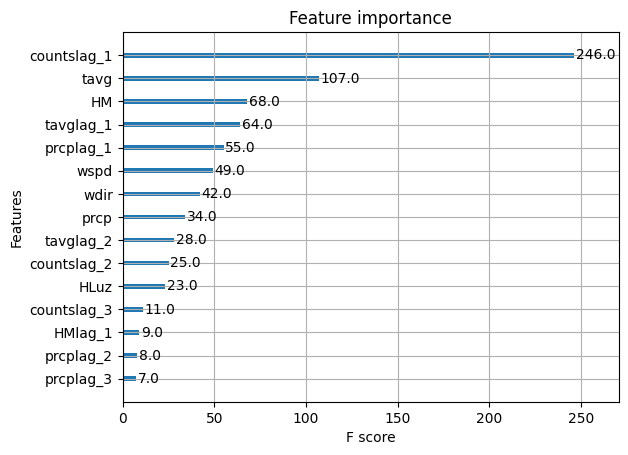

In [ ]:
# concountslag

xgb.plot_importance(model)
plt.show()

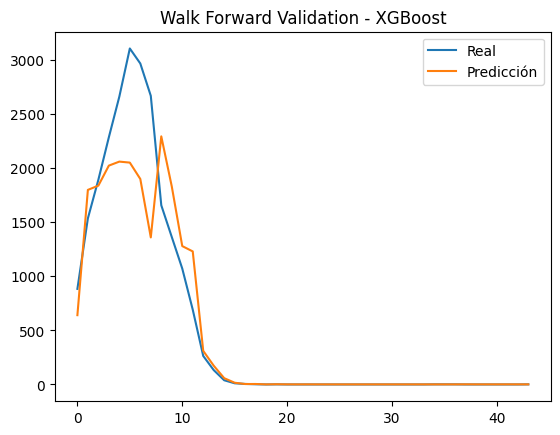

In [ ]:
#sin colineales

plt.plot(actuals, label='Real')
plt.plot(predictions, label='Predicción')
plt.legend()
plt.title("Walk Forward Validation - XGBoost")
plt.show()

## PREDECIR 2025

In [ ]:
#PREDECIR EN 2025

result25=pd.read_excel ('/content/result25conlags.xlsx')

In [ ]:
result25 = result25.drop(columns=["Unnamed: 0"])

In [ ]:
# Crear lags casos de dengue ppc y humedad temperatura

# result25['countslag_1'] = result25['y'].shift(1)
# result25['countslag_2'] = result25['y'].shift(2)
# result25['countslag_3'] = result25['y'].shift(3)

In [ ]:
# result25.dropna(inplace=True)

In [ ]:
#Ya tengo X e y definidas arriba

X = result[[
'HM', "Hmax",	"Hmin"	,"HLuz",	"tavg"	,"tmin",	"tmax",	"prcp",	"wdir",	"wspd",	"pres",
             "prcplag_1" ,"prcplag_2", "prcplag_3","countslag_1", "countslag_2" , "countslag_3",
              "tavglag_2", "tavglag_1", "HMlag_1"]]  # o las que uses

#  "countslag_1", "countslag_2" , "countslag_3", "countslag_4", "countslag_8",
            #  "prcplag_1" ,"prcplag_2", "prcplag_3",
            #  "tavglag_2", "tavglag_1", "HMlag_1"

y = result['y']

In [ ]:
#sin las colineales

X_final = result[X.columns]
y_final = result[y.name]

final_model = XGBRegressor(max_depth=5, n_estimators=50, learning_rate=0.1)
final_model.fit(X_final, y_final)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=50, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [ ]:
# #inicial con todas las variables

# X_final = result[X.columns]
# y_final = result[y.name]

# final_model = XGBRegressor(max_depth=5, n_estimators=50, learning_rate=0.1)
# final_model.fit(X_final, y_final)



XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=50, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [ ]:
# SIN LAS COLINEALES

X_future = result25[X.columns]
y_future_pred = final_model.predict(X_future)

In [ ]:
y_future_pred

array([ 1.1740619,  1.809955 ,  3.4356408,  2.5611053,  7.7219467,
        6.0851593,  6.378709 ,  5.98043  , 18.449263 , 24.003424 ,
       23.603746 , 18.718937 , 19.825212 , 19.053099 ,  9.122025 ,
       10.173729 , 11.285759 ], dtype=float32)

In [ ]:
# X_future = result25[X.columns]
# y_future_pred = final_model.predict(X_future)

In [ ]:
# y_future_pred

array([ 2.6373315,  2.6373315, 19.172216 ,  3.1172457,  4.2531915,
        3.1172457,  9.119022 ,  5.5730596, 16.943115 , 22.347282 ,
       16.943115 , 16.943115 , 16.943115 , 16.943115 ,  4.0045805,
        5.3244505,  8.370936 ], dtype=float32)

In [ ]:
result25['y_predicho'] = y_future_pred

In [ ]:
# result25.isnull().sum()

In [ ]:
#SIN LAS VARIABLES COLINEALES

y_true = result25 ["y"]
y_pred = result25['y_predicho']
# MAE
mae = mean_absolute_error(y_true, y_pred)

# RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 4.84
RMSE: 6.18


In [ ]:
y_true

,y
0,0
1,1
2,4
3,7
4,4
5,1
6,9
7,20
8,17
9,17


In [ ]:
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(y_true, y_pred)
print("MAPE:", round(mape * 100, 2), "%")

MAPE: 3.11029686861824e+16 %


In [ ]:
result25

,ds,y,year_y,semana_epidemiologica,tavg,tmin,tmax,prcp,wdir,wspd,...,prcplag_1,prcplag_2,prcplag_3,tavglag_2,tavglag_1,HMlag_1,countslag_1,countslag_2,countslag_3,y_predicho
3,2025-02-17,7,2025,7,24.485714,19.442857,29.885714,2.714286,76.285714,17.957143,...,4.685714,0.600000,7.328571,25.542857,26.228571,69.000000,4.0,1.0,0.0,3.117246
4,2025-02-24,4,2025,8,24.157143,19.985714,28.585714,0.371429,77.571429,13.057143,...,2.714286,4.685714,0.600000,26.228571,24.485714,69.000000,7.0,4.0,1.0,4.253191
5,2025-03-03,1,2025,9,25.185714,21.928571,27.600000,2.228571,136.142857,14.600000,...,0.371429,2.714286,4.685714,24.485714,24.157143,69.000000,4.0,7.0,4.0,3.117246
6,2025-03-10,9,2025,10,25.800000,22.342857,29.528571,14.300000,81.142857,13.857143,...,2.228571,0.371429,2.714286,24.157143,25.185714,69.571429,1.0,4.0,7.0,9.119022
7,2025-03-17,20,2025,11,18.900000,15.342857,22.371429,0.183333,160.714286,13.571429,...,14.300000,2.228571,0.371429,25.185714,25.800000,73.000000,9.0,1.0,4.0,5.573060
8,2025-03-24,17,2025,12,24.100000,20.900000,27.871429,6.400000,169.571429,10.657143,...,0.183333,14.300000,2.228571,25.800000,18.900000,73.000000,20.0,9.0,1.0,16.943115
9,2025-03-31,17,2025,13,21.771429,18.871429,25.485714,2.957143,96.714286,13.642857,...,6.400000,0.183333,14.300000,18.900000,24.100000,73.000000,17.0,20.0,9.0,22.347282
10,2025-04-07,25,2025,14,17.814286,13.585714,23.642857,3.971429,171.285714,11.685714,...,2.957143,6.400000,0.183333,24.100000,21.771429,73.000000,17.0,17.0,20.0,16.943115
11,2025-04-14,14,2025,15,19.457143,17.128571,21.885714,4.528571,133.571429,23.028571,...,3.971429,2.957143,6.400000,21.771429,17.814286,71.571429,25.0,17.0,17.0,16.943115
12,2025-04-21,15,2025,16,17.200000,13.742857,21.342857,0.175000,153.714286,11.028571,...,4.528571,3.971429,2.957143,17.814286,19.457143,71.000000,14.0,25.0,17.0,16.943115


In [ ]:
columnas_deseadas = ["ds", "y", "semana_epidemiologica", 'y_predicho']
predxg = result25[columnas_deseadas]
predxg

,ds,y,semana_epidemiologica,y_predicho
0,2025-01-27,0,4,1.174062
1,2025-02-03,1,5,1.809955
2,2025-02-10,4,6,3.435641
3,2025-02-17,7,7,2.561105
4,2025-02-24,4,8,7.721947
5,2025-03-03,1,9,6.085159
6,2025-03-10,9,10,6.378709
7,2025-03-17,20,11,5.980430
8,2025-03-24,17,12,18.449263
9,2025-03-31,17,13,24.003424


In [ ]:
columnas_deseadasforecast = ["yhat"]

forecastxg = forecastxg[columnas_deseadasforecast]
u3 = pd. concat([predprophet, forecast33], axis=1)
u3

In [ ]:
# columnas_deseadas = ["ds", "y", "semana_epidemiologica"]
# predprophet = result25[columnas_deseadas]
# predprophet


# columnas_deseadasforecast = ["yhat"]
# forecast33 = forecast3[columnas_deseadasforecast]
# u3 = pd. concat([predprophet, forecast33], axis=1)
# u3

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

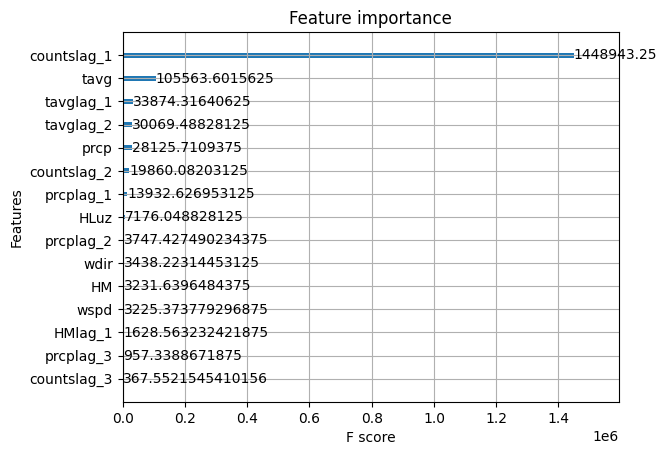

In [ ]:
# IMPORTANCIA DE LAS VARIBALES

from xgboost import plot_importance
plot_importance(model, importance_type="gain")

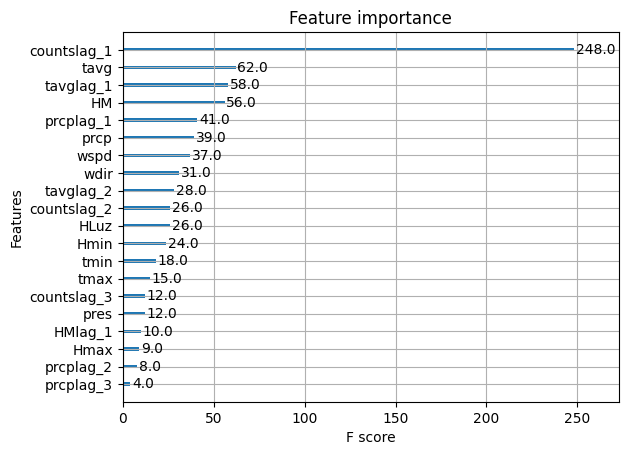

In [ ]:
#weight
xgb.plot_importance(final_model)
plt.show()

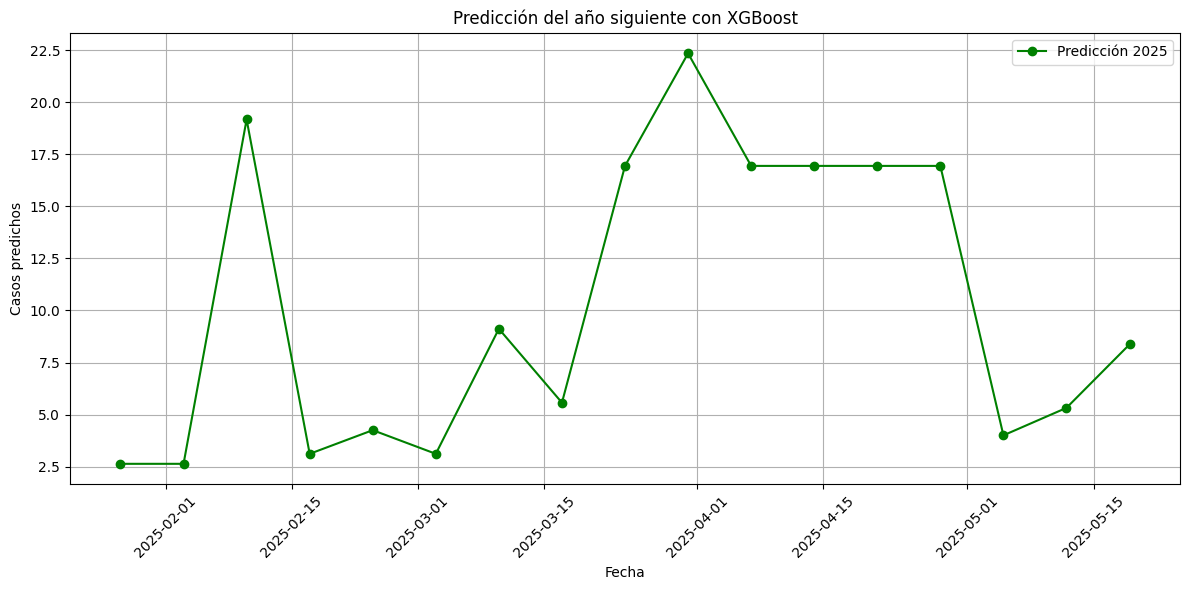

In [ ]:
import matplotlib.pyplot as plt

# Asegurarse de tener la columna de fechas
future_dates = result25['ds']

plt.figure(figsize=(12, 6))
plt.plot(future_dates, y_future_pred, label='Predicción 2025', color='green', marker='o')
plt.title('Predicción del año siguiente con XGBoost')
plt.xlabel('Fecha')
plt.ylabel('Casos predichos')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

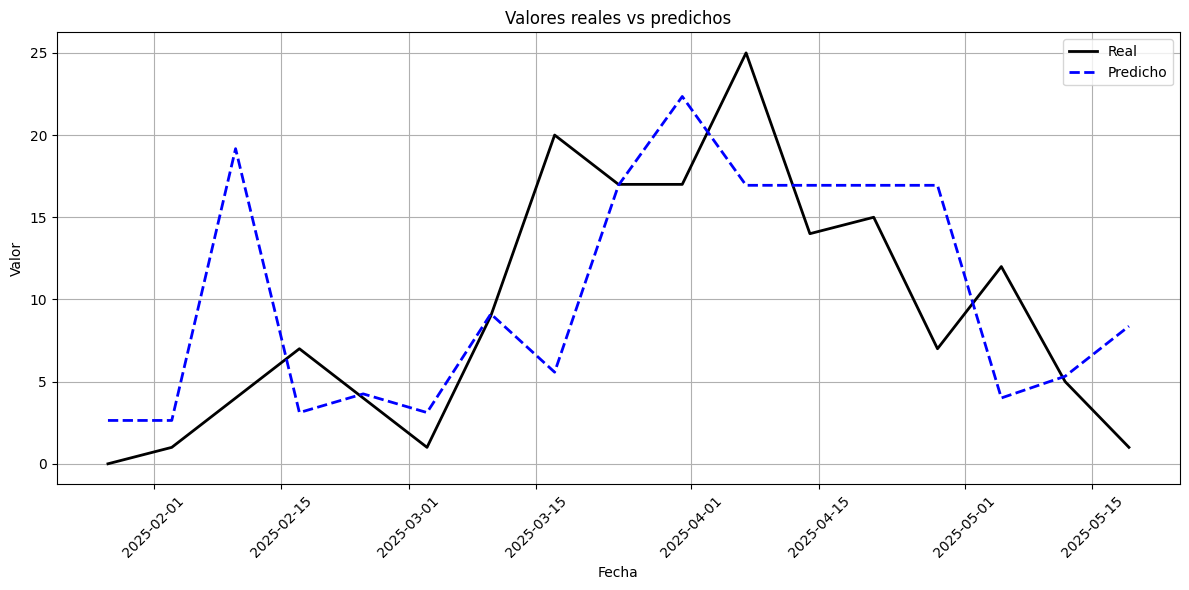

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(result25['ds'], result25['y'], label='Real', color='black', linewidth=2)
plt.plot(result25['ds'], result25['y_predicho'], label='Predicho', color='blue', linestyle='--', linewidth=2)

plt.title('Valores reales vs predichos')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


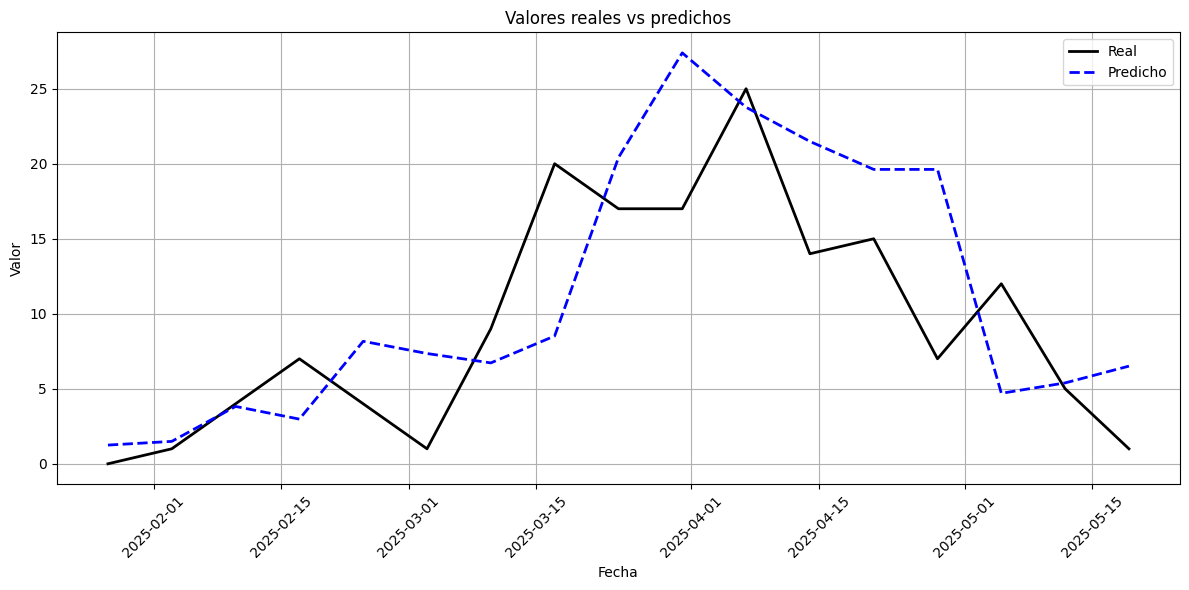

In [ ]:
#SIN LAS COLINEALES

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(result25['ds'], result25['y'], label='Real', color='black', linewidth=2)
plt.plot(result25['ds'], result25['y_predicho'], label='Predicho', color='blue', linestyle='--', linewidth=2)

plt.title('Valores reales vs predichos')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()
